In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL -1 — SMART RESTORE (Run this first every session)
# Loads saved data if it exists, skips regeneration
# ══════════════════════════════════════════════════════════════

import os
import pickle
import numpy as np
import pandas as pd

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

DRIVE_PATH = '/content/drive/MyDrive/DigitalTwin_LMP103S/'
os.makedirs(DRIVE_PATH, exist_ok=True)

CHECKPOINT_FILE = DRIVE_PATH + 'session_checkpoint.pkl'

def save_checkpoint(data_dict):
    """Save session state to Drive."""
    with open(CHECKPOINT_FILE, 'wb') as f:
        pickle.dump(data_dict, f)
    print(f"✓ Checkpoint saved to Drive.")

def load_checkpoint():
    """Load session state from Drive if it exists."""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'rb') as f:
            data = pickle.load(f)
        print(f"✓ Checkpoint loaded from Drive.")
        print(f"  Keys: {list(data.keys())}")
        return data
    else:
        print("No checkpoint found. Will regenerate data.")
        return None

# Try to load
checkpoint = load_checkpoint()

if checkpoint:
    # Restore all expensive objects
    healthy_data = checkpoint.get('healthy_data')
    fault_cat    = checkpoint.get('fault_cat')
    fault_of     = checkpoint.get('fault_of')
    fault_posc   = checkpoint.get('fault_posc')
    perf_map     = checkpoint.get('perf_map')
    print("\n✓ All simulation data restored.")
    print("  Skip Cells 0-4 and go straight to Cell 5.")
    SKIP_GENERATION = True
else:
    SKIP_GENERATION = False
    print("\nRun Cells 0-4 to generate data, then save checkpoint.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
No checkpoint found. Will regenerate data.

Run Cells 0-4 to generate data, then save checkpoint.


In [ ]:
# ── Model restore ──────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

MODEL_PATH  = DRIVE_PATH + 'combustion_lstm_model.keras'
SCALER_PATH = DRIVE_PATH + 'scaler_params.json'

if os.path.exists(MODEL_PATH):
    model = keras.models.load_model(MODEL_PATH)
    with open(SCALER_PATH) as f:
        sp = json.load(f)
    scaler = StandardScaler()
    scaler.mean_  = np.array(sp['mean'])
    scaler.scale_ = np.array(sp['scale'])
    # Also need these constants
    FEATURES = ['P_c_meas','T_c_meas','thrust_meas',
                'mdot_ox_meas','mdot_fuel_meas','cstar_eff_meas']
    WINDOW_SIZE = 50
    fault_map   = {'healthy':0,'catalyst_degradation':1,
                   'OF_drift':2,'pressure_oscillation':3}
    n_cls = 4
    G0    = 9.80665
    print("✓ Model and scaler restored from Drive.")
    print("  Can run Cells 10-13 directly.")
else:
    print("Model not found. Run Cell 6 first.")

Model not found. Run Cell 6 first.


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 0 — Master Setup
# Digital Twin: Rocket Combustion Chamber Diagnostics
# Prashant Gahlot | University of Bologna | 2026
# Paper 2: Extending LMP-103S thermochemical analysis
#          into real-time health monitoring framework
# ══════════════════════════════════════════════════════════════

!pip install cantera -q

import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import json
import os
from scipy import signal
from scipy.interpolate import interp1d

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi'      : 150,
    'font.family'     : 'serif',
    'font.size'       : 10,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'lines.linewidth' : 1.5,
})

print(f"Cantera {ct.__version__} ready.")

# ── Constants ──────────────────────────────────────────────────
G0       = 9.80665       # m/s²
R_UNIV   = 8314.0        # J/kmol/K
P_CHAMBER= 25.0          # bar (nominal, from Paper 1)
OF_NOM   = 6.0           # nominal O/F ratio
DT_SIM   = 0.01          # simulation timestep (seconds)
T_TOTAL  = 100.0         # total simulation duration (seconds)

# LMP-103S decomposition (from Paper 1)
LMP103S  = {'N2': 0.3789, 'H2O': 0.4554, 'O2': 0.1657}
MW_LMP   = 24.11         # g/mol
MW_FUEL  = 46.07         # ethanol g/mol (best performer from Paper 1)

# ── Core equilibrium function (from Paper 1) ──────────────────
def combustion_equilibrium(OF_mass, P_bar=P_CHAMBER,
                            catalyst_eff=1.0):
    """
    Compute equilibrium combustion state.

    catalyst_eff: 0.0-1.0, scales active O2 fraction
                  1.0 = fresh catalyst (nominal)
                  0.7 = degraded catalyst (fault condition)
                  Models real-world ADN catalyst bed degradation
    """
    gas = ct.Solution('gri30.yaml')
    P_pa = P_bar * 1e5

    # Apply catalyst efficiency — degraded catalyst
    # produces less O2 from ADN decomposition
    ox = {
        'O2' : LMP103S['O2']  * catalyst_eff,
        'N2' : LMP103S['N2'],
        'H2O': LMP103S['H2O'] + LMP103S['O2'] * (1 - catalyst_eff),
    }
    # Renormalise
    total = sum(ox.values())
    ox    = {k: v/total for k, v in ox.items()}
    MW_ox = ox['O2']*32 + ox['N2']*28 + ox['H2O']*18

    mole_ratio = OF_mass * (MW_FUEL / MW_ox)
    mixture    = {}
    for sp, xf in ox.items():
        mixture[sp] = mixture.get(sp, 0) + xf * mole_ratio
    for sp, m in {'C2H4': 1.0, 'H2': 1.0}.items():
        mixture[sp] = mixture.get(sp, 0) + m

    gas.TPX = 300.0, P_pa, mixture
    gas.equilibrate('HP')

    T     = gas.T
    gam   = gas.cp / gas.cv
    MW    = gas.mean_molecular_weight
    R     = R_UNIV / MW
    Gvdk  = np.sqrt(gam) * (2/(gam+1))**((gam+1)/(2*(gam-1)))
    cstar = np.sqrt(R * T) / Gvdk
    Cf    = Gvdk * np.sqrt(2*gam/(gam-1)*(1-(1e5/P_pa)**((gam-1)/gam)))
    Isp   = Cf * cstar / G0

    # Species of diagnostic interest
    species_idx = {sp: gas.species_index(sp)
                   for sp in ['H2O','CO2','CO','H2','N2','OH','O2']
                   if sp in gas.species_names}
    exhaust = {sp: float(gas.X[idx])
               for sp, idx in species_idx.items()}

    return {
        'T_c'    : T,
        'Isp'    : Isp,
        'c_star' : cstar,
        'gamma'  : gam,
        'MW_ex'  : MW,
        'exhaust': exhaust,
        'P_bar'  : P_bar,
        'OF'     : OF_mass,
        'cat_eff': catalyst_eff,
    }

# ── Quick verification ─────────────────────────────────────────
r = combustion_equilibrium(OF_NOM, P_CHAMBER, 1.0)
print(f"\nNominal operating point verification:")
print(f"  O/F={OF_NOM}, P={P_CHAMBER}bar, catalyst_eff=1.0")
print(f"  T_c    = {r['T_c']:.1f} K")
print(f"  Isp    = {r['Isp']:.2f} s")
print(f"  c*     = {r['c_star']:.1f} m/s")
print(f"\n✓ Cell 0 complete. Core physics model ready.")
print(f"  This extends Paper 1 results into time-domain simulation.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 7.9 MB/s eta 0:00:00
Cantera 3.2.0 ready.

Nominal operating point verification:
  O/F=6.0, P=25.0bar, catalyst_eff=1.0
  T_c    = 1682.3 K
  Isp    = 181.54 s
  c*     = 1240.5 m/s

✓ Cell 0 complete. Core physics model ready.
  This extends Paper 1 results into time-domain simulation.


Building Digital Twin physics layer...
Pre-computing performance map across operating envelope...
  50/714 (7%)
  100/714 (14%)
  150/714 (21%)
  200/714 (28%)
  250/714 (35%)
  300/714 (42%)
  350/714 (49%)
  400/714 (56%)
  450/714 (63%)
  500/714 (70%)
  550/714 (77%)
  600/714 (84%)
  650/714 (91%)
  700/714 (98%)
Performance map complete: 714 points

Nominal grid: P=25.0bar, cat=1.0, OF=6.0
T_c range (O/F sweep):  1128.2 – 1965.3 K
Isp range (O/F sweep):  163.24 – 188.24 s
T_c range (cat sweep):  1008.9 – 1682.3 K

Interpolators built.
  Test O/F=6.0: T_c=1682.3K  Isp=181.54s
  Test cat=0.75: T_c=1300.9K  Isp=161.66s


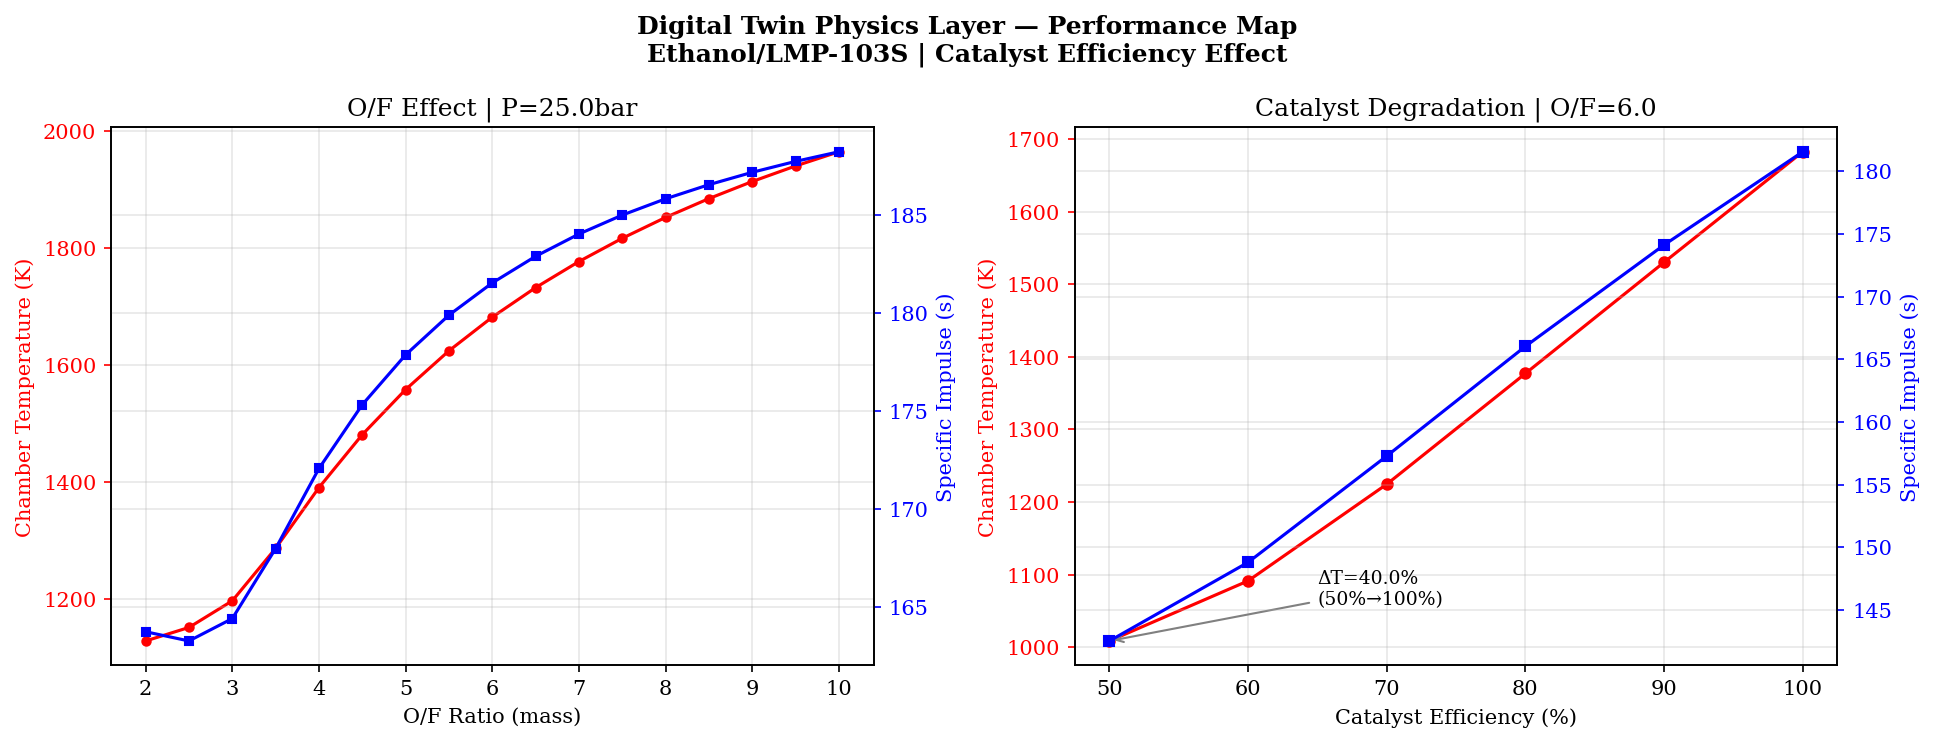


Performance map saved.

✓ Cell 1 complete.
  Catalyst 100%→50% degradation:
  T_c: 1682.3K → 1008.9K  (40.0% drop)
  This is the primary fault signature for Cell 3.


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 1 — Performance Map and Lookup Tables (FIXED)
# ══════════════════════════════════════════════════════════════

print("Building Digital Twin physics layer...")
print("Pre-computing performance map across operating envelope...")

# Operating envelope
OF_RANGE   = np.linspace(2, 10, 17)
P_RANGE    = np.linspace(10, 40, 7)
CAT_RANGE  = np.linspace(0.5, 1.0, 6)

# Round all grid values upfront to avoid float precision issues
OF_grid  = [round(float(x), 2) for x in OF_RANGE]
P_grid   = [round(float(x), 1) for x in P_RANGE]
cat_grid = [round(float(x), 2) for x in CAT_RANGE]

# Nested dict: perf_map[OF][P][cat]
perf_map = {}
total    = len(OF_grid) * len(P_grid) * len(cat_grid)
count    = 0

for OF in OF_grid:
    perf_map[OF] = {}
    for P in P_grid:
        perf_map[OF][P] = {}
        for cat in cat_grid:
            try:
                r = combustion_equilibrium(OF, P, cat)
                perf_map[OF][P][cat] = {
                    'T_c'   : r['T_c'],
                    'Isp'   : r['Isp'],
                    'c_star': r['c_star'],
                    'gamma' : r['gamma'],
                    'MW_ex' : r['MW_ex'],
                }
            except Exception as e:
                perf_map[OF][P][cat] = None
            count += 1
            if count % 50 == 0:
                print(f"  {count}/{total} ({count/total*100:.0f}%)")

print(f"Performance map complete: {count} points")

# Find closest grid values to nominal P=25, cat=1.0
P_nom_grid   = min(P_grid,   key=lambda x: abs(x - 25.0))
cat_nom_grid = min(cat_grid, key=lambda x: abs(x - 1.0))
OF_nom_grid  = min(OF_grid,  key=lambda x: abs(x - 6.0))

print(f"\nNominal grid: P={P_nom_grid}bar, cat={cat_nom_grid}, "
      f"OF={OF_nom_grid}")

# Build arrays for interpolation
OF_arr  = np.array(OF_grid)
T_nom   = np.array([perf_map[OF][P_nom_grid][cat_nom_grid]['T_c']
                    for OF in OF_grid])
Isp_nom = np.array([perf_map[OF][P_nom_grid][cat_nom_grid]['Isp']
                    for OF in OF_grid])
cs_nom  = np.array([perf_map[OF][P_nom_grid][cat_nom_grid]['c_star']
                    for OF in OF_grid])

# Catalyst degradation arrays
cat_arr  = np.array(cat_grid)
T_cat    = np.array([perf_map[OF_nom_grid][P_nom_grid][cat]['T_c']
                     for cat in cat_grid])
Isp_cat  = np.array([perf_map[OF_nom_grid][P_nom_grid][cat]['Isp']
                     for cat in cat_grid])

print(f"T_c range (O/F sweep):  {T_nom.min():.1f} – {T_nom.max():.1f} K")
print(f"Isp range (O/F sweep):  {Isp_nom.min():.2f} – {Isp_nom.max():.2f} s")
print(f"T_c range (cat sweep):  {T_cat.min():.1f} – {T_cat.max():.1f} K")

# Build interpolators
from scipy.interpolate import interp1d

interp_T_OF    = interp1d(OF_arr,  T_nom,   kind='cubic',
                           fill_value='extrapolate')
interp_Isp_OF  = interp1d(OF_arr,  Isp_nom, kind='cubic',
                           fill_value='extrapolate')
interp_cs_OF   = interp1d(OF_arr,  cs_nom,  kind='cubic',
                           fill_value='extrapolate')
interp_T_cat   = interp1d(cat_arr, T_cat,   kind='linear',
                           fill_value='extrapolate')
interp_Isp_cat = interp1d(cat_arr, Isp_cat, kind='linear',
                           fill_value='extrapolate')

print("\nInterpolators built.")
print(f"  Test O/F=6.0: T_c={interp_T_OF(6.0):.1f}K  "
      f"Isp={interp_Isp_OF(6.0):.2f}s")
print(f"  Test cat=0.75: T_c={interp_T_cat(0.75):.1f}K  "
      f"Isp={interp_Isp_cat(0.75):.2f}s")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Digital Twin Physics Layer — Performance Map\n'
             'Ethanol/LMP-103S | Catalyst Efficiency Effect',
             fontweight='bold')

ax1      = axes[0]
ax1_twin = ax1.twinx()
ax1.plot(OF_arr, T_nom,    'r-o', ms=4, label='$T_c$')
ax1_twin.plot(OF_arr, Isp_nom, 'b-s', ms=4, label='$I_{sp}$')
ax1.set_xlabel('O/F Ratio (mass)')
ax1.set_ylabel('Chamber Temperature (K)', color='red')
ax1_twin.set_ylabel('Specific Impulse (s)', color='blue')
ax1.set_title(f'O/F Effect | P={P_nom_grid}bar')
ax1.tick_params(axis='y', colors='red')
ax1_twin.tick_params(axis='y', colors='blue')

ax2      = axes[1]
ax2_twin = ax2.twinx()
ax2.plot(cat_arr*100, T_cat,    'r-o', ms=5)
ax2_twin.plot(cat_arr*100, Isp_cat, 'b-s', ms=5)
ax2.set_xlabel('Catalyst Efficiency (%)')
ax2.set_ylabel('Chamber Temperature (K)', color='red')
ax2_twin.set_ylabel('Specific Impulse (s)', color='blue')
ax2.set_title(f'Catalyst Degradation | O/F={OF_nom_grid}')
ax2.tick_params(axis='y', colors='red')
ax2_twin.tick_params(axis='y', colors='blue')

dT = (T_cat[-1] - T_cat[0]) / T_cat[-1] * 100
ax2.annotate(f'ΔT={dT:.1f}%\n(50%→100%)',
             xy=(cat_arr[0]*100, T_cat[0]),
             xytext=(65, T_cat[0]+50),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=9)

plt.tight_layout()
plt.savefig('dt_fig1_performance_map.png', dpi=200, bbox_inches='tight')
plt.show()

# Save as JSON
def perf_map_to_list(pm):
    out = []
    for OF, p_dict in pm.items():
        for P, c_dict in p_dict.items():
            for cat, vals in c_dict.items():
                if vals:
                    out.append({'OF':OF,'P':P,'cat':cat,**vals})
    return out

with open('performance_map.json', 'w') as f:
    json.dump(perf_map_to_list(perf_map), f, indent=2)

print("\nPerformance map saved.")
print(f"\n✓ Cell 1 complete.")
print(f"  Catalyst 100%→50% degradation:")
print(f"  T_c: {T_cat[-1]:.1f}K → {T_cat[0]:.1f}K  ({dT:.1f}% drop)")
print(f"  This is the primary fault signature for Cell 3.")

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 2 — Sensor Model + Healthy Operating Data
# Simulates realistic sensor readings from the combustion chamber
# Adds measurement noise, sensor drift, and sampling effects
# ══════════════════════════════════════════════════════════════

class CombustionChamberSensor:
    """
    Physics-based sensor model for combustion chamber.

    Sensors modelled:
    1. Chamber pressure transducer (Pc)
    2. Chamber temperature sensor (T_c) — thermocouple
    3. Thrust load cell (F)
    4. Propellant flow meters (mdot_ox, mdot_fuel)
    5. Combustion efficiency proxy (c* efficiency)

    Noise characteristics based on typical aerospace-grade
    sensor specifications.
    """

    def __init__(self, dt=DT_SIM):
        self.dt = dt

        # Sensor noise (1-sigma, % of reading)
        self.noise = {
            'P_c'      : 0.005,   # 0.5% — pressure transducer
            'T_c'      : 0.020,   # 2.0% — thermocouple
            'thrust'   : 0.010,   # 1.0% — load cell
            'mdot_ox'  : 0.015,   # 1.5% — flow meter
            'mdot_fuel': 0.015,   # 1.5% — flow meter
            'cstar_eff': 0.008,   # 0.8% — derived metric
        }

        # Sensor time constants (seconds) — first-order lag
        self.tau = {
            'P_c'      : 0.05,   # fast — pressure
            'T_c'      : 2.00,   # slow — thermal mass
            'thrust'   : 0.10,   # medium — mechanical
            'mdot_ox'  : 0.20,   # medium — flow
            'mdot_fuel': 0.20,
            'cstar_eff': 0.50,
        }

        # Sensor state (for lag simulation)
        self._state = {}

    def measure(self, true_values, t):
        """
        Apply sensor model to true physics values.
        Returns dict of noisy sensor readings.
        """
        readings = {}

        for sensor, true_val in true_values.items():
            if sensor not in self.noise:
                readings[sensor] = true_val
                continue

            # 1. Gaussian measurement noise
            noise_sigma = self.noise[sensor] * abs(true_val)
            noisy = true_val + np.random.normal(0, noise_sigma)

            # 2. First-order sensor lag (RC filter)
            tau = self.tau[sensor]
            alpha = self.dt / (tau + self.dt)
            if sensor not in self._state:
                self._state[sensor] = noisy
            self._state[sensor] = (alpha * noisy +
                                   (1 - alpha) * self._state[sensor])

            readings[sensor] = self._state[sensor]

        return readings


def generate_healthy_data(duration=T_TOTAL, dt=DT_SIM,
                           OF_nom=OF_NOM, P_nom=P_CHAMBER):
    """
    Generate healthy operating data with realistic variation.

    Models normal combustion chamber operation with:
    - Slow O/F ratio drift (±5% around nominal)
    - Pressure oscillations (±2%)
    - All sensors at nominal values + measurement noise
    """
    t_arr    = np.arange(0, duration, dt)
    N        = len(t_arr)
    sensor   = CombustionChamberSensor(dt)

    # Storage
    data = {
        't'         : t_arr,
        'OF_true'   : np.zeros(N),
        'P_true'    : np.zeros(N),
        'cat_eff'   : np.ones(N),    # healthy: always 1.0
        'T_c_true'  : np.zeros(N),
        'Isp_true'  : np.zeros(N),
        'cstar_true': np.zeros(N),
        # Sensor readings (noisy)
        'P_c_meas'  : np.zeros(N),
        'T_c_meas'  : np.zeros(N),
        'thrust_meas': np.zeros(N),
        'mdot_ox_meas'  : np.zeros(N),
        'mdot_fuel_meas': np.zeros(N),
        'cstar_eff_meas': np.zeros(N),
        'label'     : np.zeros(N, dtype=int),  # 0=healthy
        'fault_type': ['healthy'] * N,
    }

    # Typical thruster parameters
    throat_area  = 1.5e-4   # m² — nozzle throat area
    m_dot_total  = 0.050    # kg/s — total propellant flow

    print(f"Generating healthy data: {duration}s at {dt}s timestep")
    print(f"  N = {N} samples")

    for i, t in enumerate(t_arr):

        # Realistic O/F variation — slow sinusoidal + random walk
        OF_variation = (
            0.15 * np.sin(2*np.pi*t/30) +   # 30s period oscillation
            0.05 * np.sin(2*np.pi*t/7) +    # 7s period
            np.random.normal(0, 0.03)         # random noise
        )
        OF = np.clip(OF_nom + OF_variation, 3.0, 9.5)

        # Pressure variation
        P_variation = (
            0.3 * np.sin(2*np.pi*t/15) +
            np.random.normal(0, 0.2)
        )
        P = np.clip(P_nom + P_variation, 18, 32)

        # Get true physics state
        T_c  = float(interp_T_OF(OF))
        Isp  = float(interp_Isp_OF(OF))
        cstar= float(interp_cs_OF(OF))

        # Derived physical quantities
        # Thrust = mdot * Ve = mdot * Isp * g0
        thrust = m_dot_total * Isp * G0

        # Flow rates (mass-based O/F)
        mdot_fuel = m_dot_total / (1 + OF)
        mdot_ox   = m_dot_total - mdot_fuel

        # c* efficiency (ratio of actual to theoretical)
        cstar_eff = 0.96 + np.random.normal(0, 0.005)

        # Store true values
        data['OF_true'][i]    = OF
        data['P_true'][i]     = P
        data['T_c_true'][i]   = T_c
        data['Isp_true'][i]   = Isp
        data['cstar_true'][i] = cstar

        # Apply sensor model
        true_vals = {
            'P_c'      : P,
            'T_c'      : T_c,
            'thrust'   : thrust,
            'mdot_ox'  : mdot_ox,
            'mdot_fuel': mdot_fuel,
            'cstar_eff': cstar_eff,
        }
        readings = sensor.measure(true_vals, t)

        data['P_c_meas'][i]       = readings['P_c']
        data['T_c_meas'][i]       = readings['T_c']
        data['thrust_meas'][i]    = readings['thrust']
        data['mdot_ox_meas'][i]   = readings['mdot_ox']
        data['mdot_fuel_meas'][i] = readings['mdot_fuel']
        data['cstar_eff_meas'][i] = readings['cstar_eff']

    print(f"  Done. Healthy data generated.")
    return data


# Generate healthy dataset
healthy_data = generate_healthy_data(
    duration=200.0,   # 200 seconds of healthy operation
    dt=DT_SIM,
    OF_nom=OF_NOM,
    P_nom=P_CHAMBER
)

print(f"\nHealthy data summary:")
print(f"  Duration : {healthy_data['t'][-1]:.0f} s")
print(f"  Samples  : {len(healthy_data['t'])}")
print(f"  O/F range: {healthy_data['OF_true'].min():.2f} – "
      f"{healthy_data['OF_true'].max():.2f}")
print(f"  T_c range: {healthy_data['T_c_meas'].min():.1f} – "
      f"{healthy_data['T_c_meas'].max():.1f} K")
print(f"  Thrust rng: {healthy_data['thrust_meas'].min():.1f} – "
      f"{healthy_data['thrust_meas'].max():.1f} N")
print("\n✓ Cell 2 complete.")

Generating healthy data: 200.0s at 0.01s timestep
  N = 20000 samples
  Done. Healthy data generated.

Healthy data summary:
  Duration : 200 s
  Samples  : 20000
  O/F range: 5.72 – 6.29
  T_c range: 1661.6 – 1701.1 K
  Thrust rng: 88.1 – 89.9 N

✓ Cell 2 complete.


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 3 — Fault Injection: Three Fault Modes
# Generates labelled fault data for ML training
#
# Fault 1: Catalyst Degradation
#   Gradual reduction in ADN decomposition efficiency
#   Physical mechanism: catalyst sintering/poisoning
#   Sensor signature: slow T_c decrease, c* drop
#
# Fault 2: O/F Drift (Injector Degradation)
#   Injector orifice erosion → fuel-rich drift
#   Physical mechanism: propellant deposit buildup
#   Sensor signature: mdot_fuel increase, O/F shift
#
# Fault 3: Chamber Pressure Oscillation (Combustion Instability)
#   High-frequency pressure oscillations
#   Physical mechanism: acoustic-combustion coupling
#   Sensor signature: P_c variance increase
# ══════════════════════════════════════════════════════════════

def generate_fault_data(fault_type, duration=150.0,
                         dt=DT_SIM, onset_time=50.0,
                         severity=0.3):
    """
    Generate faulty operating data with labelled fault onset.

    fault_type: 'catalyst_degradation' | 'OF_drift' |
                'pressure_oscillation'
    onset_time: when fault begins (seconds)
    severity  : 0=no fault, 1=maximum fault severity
    """
    t_arr  = np.arange(0, duration, dt)
    N      = len(t_arr)
    sensor = CombustionChamberSensor(dt)

    data = {
        't'              : t_arr,
        'OF_true'        : np.zeros(N),
        'P_true'         : np.zeros(N),
        'cat_eff'        : np.ones(N),
        'T_c_true'       : np.zeros(N),
        'Isp_true'       : np.zeros(N),
        'cstar_true'     : np.zeros(N),
        'P_c_meas'       : np.zeros(N),
        'T_c_meas'       : np.zeros(N),
        'thrust_meas'    : np.zeros(N),
        'mdot_ox_meas'   : np.zeros(N),
        'mdot_fuel_meas' : np.zeros(N),
        'cstar_eff_meas' : np.zeros(N),
        'label'          : np.zeros(N, dtype=int),
        'fault_type'     : ['healthy'] * N,
    }

    m_dot_total = 0.050  # kg/s

    for i, t in enumerate(t_arr):

        # Fault progression — sigmoid onset
        if t < onset_time:
            fault_progress = 0.0
            label = 0
        else:
            # Smooth sigmoid progression
            tau_fault = 10.0  # fault rise time constant
            fault_progress = severity * (
                1 - np.exp(-(t - onset_time) / tau_fault)
            )
            label = 1

        data['label'][i] = label
        if label == 1:
            data['fault_type'][i] = fault_type

        # ── Apply fault-specific physics ───────────────────────
        OF_base = OF_NOM + (
            0.15*np.sin(2*np.pi*t/30) +
            0.05*np.sin(2*np.pi*t/7) +
            np.random.normal(0, 0.03)
        )

        if fault_type == 'catalyst_degradation':
            # Catalyst efficiency degrades from 1.0 to (1-severity)
            cat_eff = 1.0 - fault_progress
            cat_eff = max(cat_eff, 0.5)
            data['cat_eff'][i] = cat_eff

            OF = np.clip(OF_base, 3.0, 9.5)
            P  = P_CHAMBER + 0.3*np.sin(2*np.pi*t/15) + \
                 np.random.normal(0, 0.2)

            # Use catalyst efficiency to scale T_c and Isp
            T_c_nom  = float(interp_T_OF(OF))
            Isp_nom_ = float(interp_Isp_OF(OF))
            cstar_n  = float(interp_cs_OF(OF))

            T_c_deg  = float(interp_T_cat(cat_eff))
            scale    = T_c_deg / T_cat[-1]   # degradation ratio

            T_c   = T_c_nom  * scale
            Isp   = Isp_nom_ * scale
            cstar = cstar_n  * scale

            cstar_eff = 0.96 * scale

        elif fault_type == 'OF_drift':
            # O/F drifts fuel-rich due to injector erosion
            # Erosion increases fuel orifice area → more fuel flow
            OF_drift = OF_base - fault_progress * 2.5
            OF = np.clip(OF_drift, 2.0, 9.5)
            P  = P_CHAMBER + np.random.normal(0, 0.3)
            cat_eff = 1.0

            T_c   = float(interp_T_OF(OF))
            Isp   = float(interp_Isp_OF(OF))
            cstar = float(interp_cs_OF(OF))
            cstar_eff = 0.96

        elif fault_type == 'pressure_oscillation':
            # High frequency pressure oscillation
            # Models thermoacoustic instability onset
            OF = np.clip(OF_base, 3.0, 9.5)
            P_osc_amp = fault_progress * 3.0  # bar amplitude
            P_osc_freq = 250.0  # Hz — typical 1st tangential mode
            P = (P_CHAMBER +
                 0.3*np.sin(2*np.pi*t/15) +
                 P_osc_amp * np.sin(2*np.pi * P_osc_freq * t) +
                 np.random.normal(0, 0.2))
            cat_eff = 1.0

            T_c   = float(interp_T_OF(OF))
            Isp   = float(interp_Isp_OF(OF))
            cstar = float(interp_cs_OF(OF))
            cstar_eff = 0.96 - fault_progress * 0.05

        else:
            raise ValueError(f"Unknown fault: {fault_type}")

        # Store true state
        data['OF_true'][i]    = OF
        data['P_true'][i]     = P
        data['cat_eff'][i]    = cat_eff
        data['T_c_true'][i]   = T_c
        data['Isp_true'][i]   = Isp
        data['cstar_true'][i] = cstar

        # Derived quantities
        thrust     = m_dot_total * Isp * G0
        mdot_fuel  = m_dot_total / (1 + OF)
        mdot_ox    = m_dot_total - mdot_fuel

        # Sensor model
        true_vals = {
            'P_c'      : P,
            'T_c'      : T_c,
            'thrust'   : thrust,
            'mdot_ox'  : mdot_ox,
            'mdot_fuel': mdot_fuel,
            'cstar_eff': cstar_eff,
        }
        readings = sensor.measure(true_vals, t)

        data['P_c_meas'][i]       = readings['P_c']
        data['T_c_meas'][i]       = readings['T_c']
        data['thrust_meas'][i]    = readings['thrust']
        data['mdot_ox_meas'][i]   = readings['mdot_ox']
        data['mdot_fuel_meas'][i] = readings['mdot_fuel']
        data['cstar_eff_meas'][i] = readings['cstar_eff']

    return data


# Generate all three fault datasets
print("Generating fault datasets...")

fault_cat  = generate_fault_data('catalyst_degradation',
                                   duration=150, onset_time=50,
                                   severity=0.4)
fault_of   = generate_fault_data('OF_drift',
                                   duration=150, onset_time=50,
                                   severity=0.35)
fault_posc = generate_fault_data('pressure_oscillation',
                                   duration=150, onset_time=50,
                                   severity=0.5)

print(f"\nFault dataset summary:")
for name, data in [('Catalyst Degradation', fault_cat),
                   ('O/F Drift',            fault_of),
                   ('Pressure Oscillation', fault_posc)]:
    n_fault = sum(data['label'])
    pct     = n_fault / len(data['label']) * 100
    print(f"  {name:25s}: {len(data['t'])} samples, "
          f"{n_fault} faulty ({pct:.0f}%)")

print("\n✓ Cell 3 complete. Three fault modes generated.")

Generating fault datasets...

Fault dataset summary:
  Catalyst Degradation     : 15000 samples, 10000 faulty (67%)
  O/F Drift                : 15000 samples, 10000 faulty (67%)
  Pressure Oscillation     : 15000 samples, 10000 faulty (67%)

✓ Cell 3 complete. Three fault modes generated.


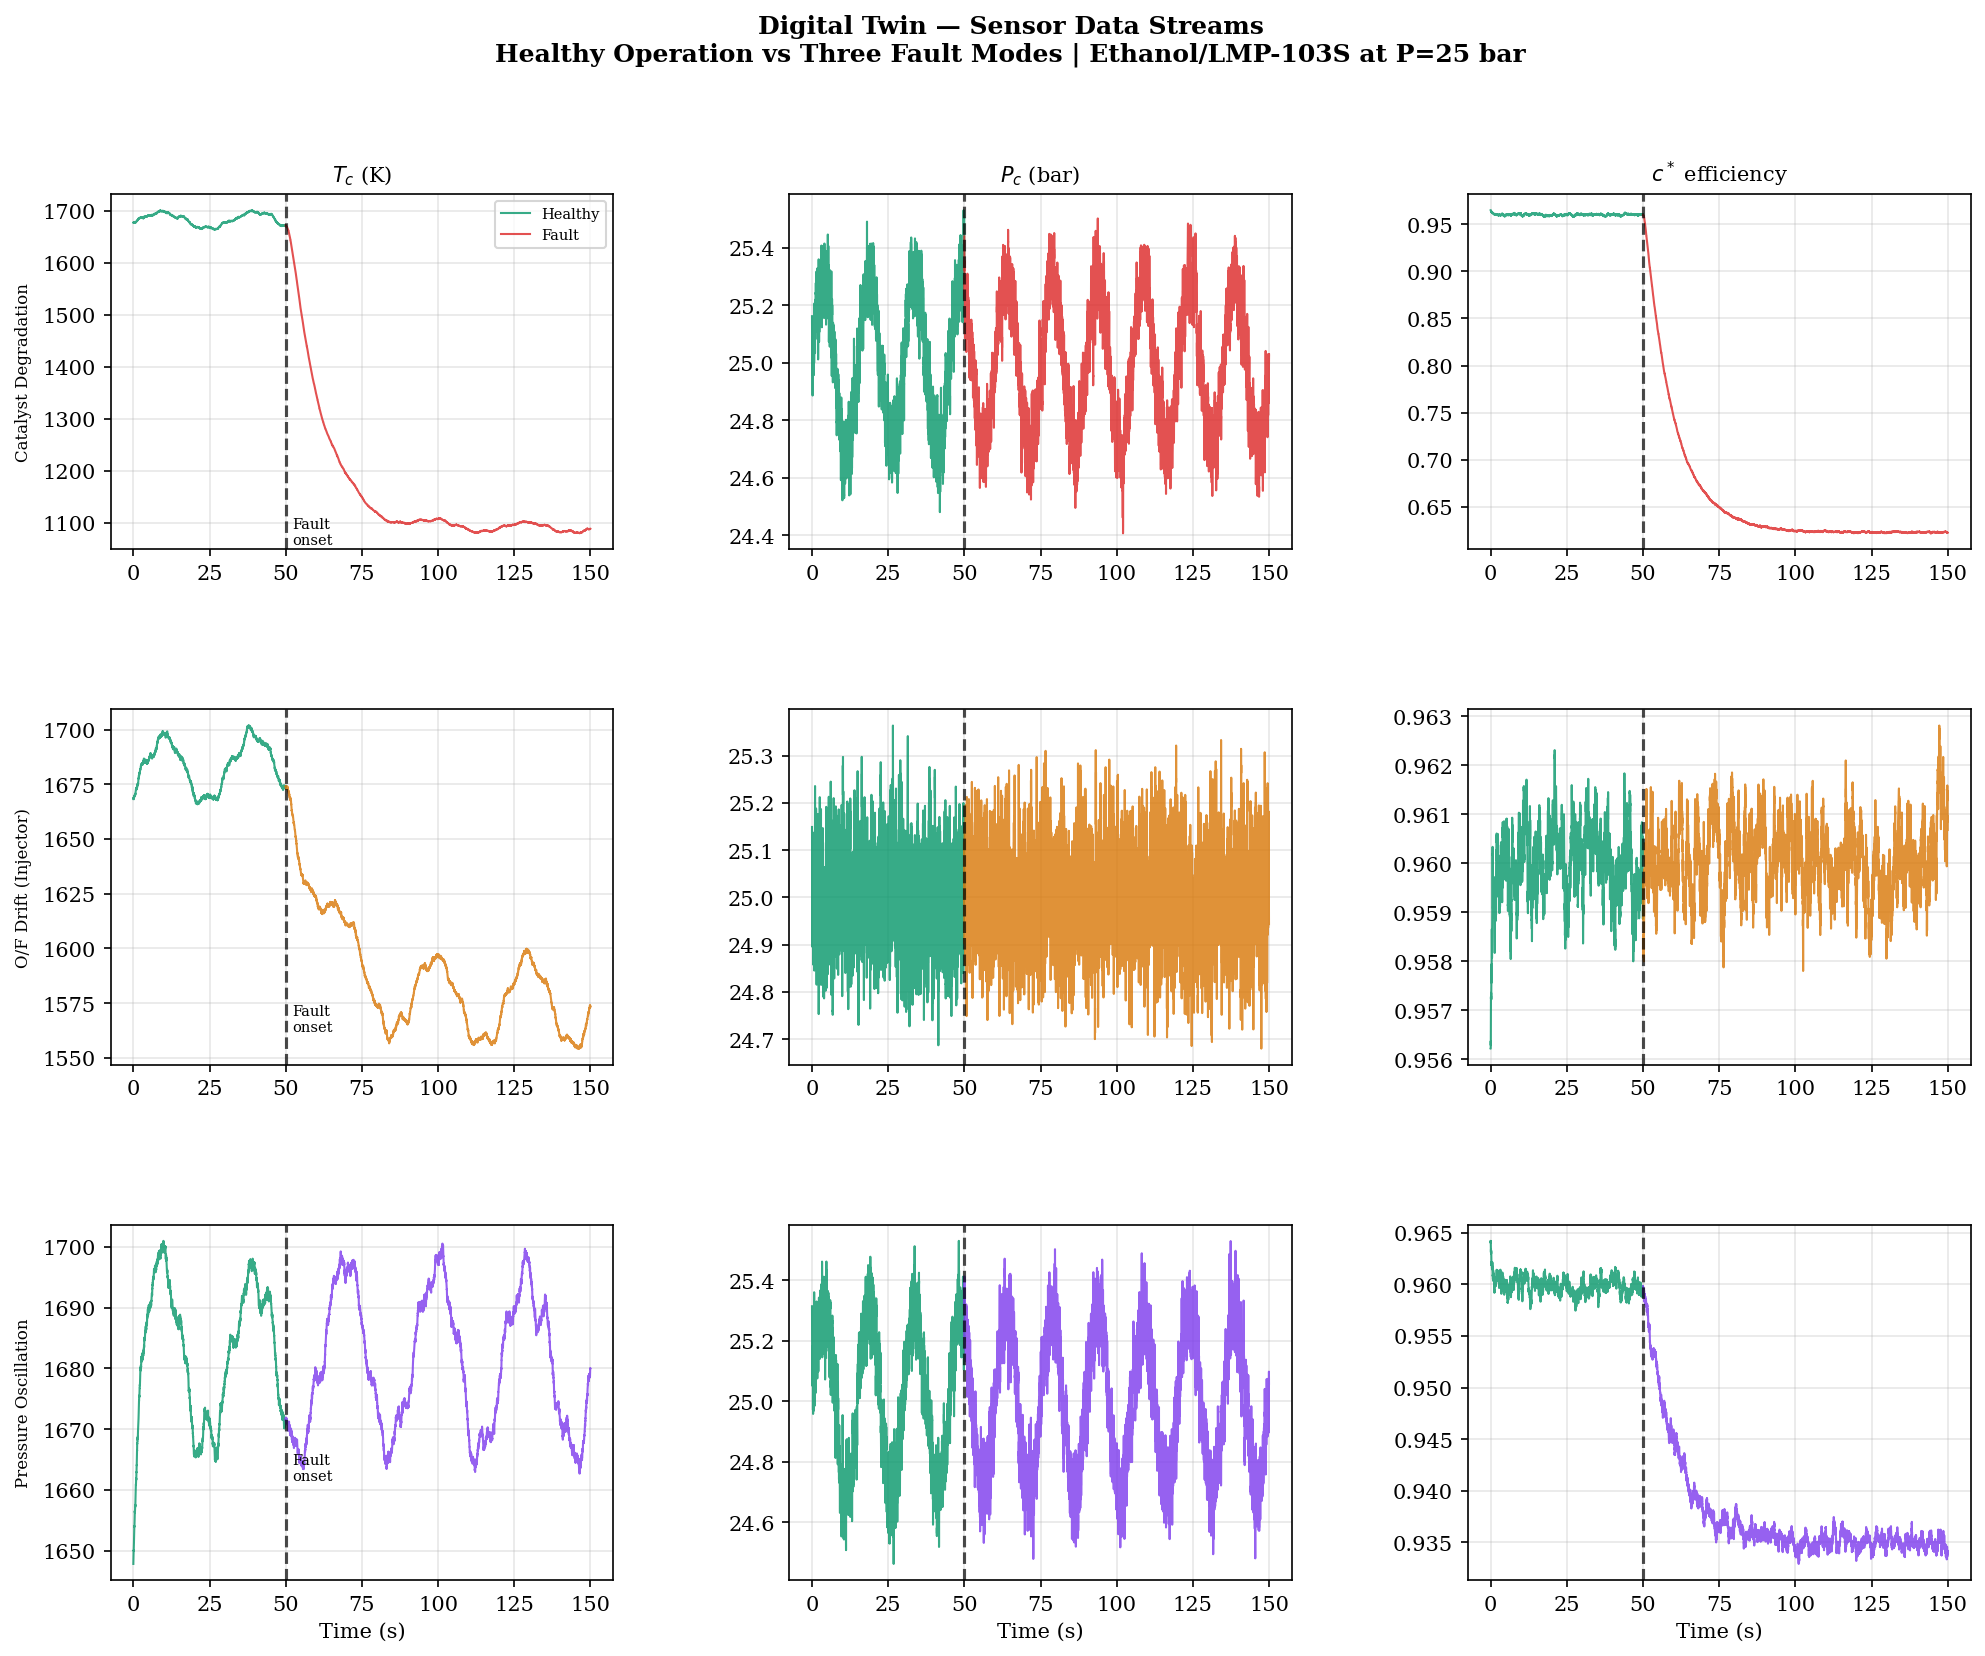

Combining all datasets...

Full dataset saved: combustion_dt_dataset.csv
  Total samples : 65000
  Healthy       : 35000
  Faulty        : 30000
  Features      : 11
  Fault types   : ['healthy' 'catalyst_degradation' 'OF_drift' 'pressure_oscillation']

DAY 3 COMPLETE
✓ Physics model built and verified
✓ Performance map computed (714 operating points)
✓ Sensor model with realistic noise and lag
✓ 3 fault modes injected with physics-based signatures
✓ Labelled training dataset generated and saved

Dataset ready for ML training on Day 4.
Tomorrow: LSTM anomaly detection model
✓ Checkpoint saved to Drive.
Checkpoint saved. Future sessions load in 30 seconds.


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 4 — Visualise Fault Signatures + Save Full Dataset
# ══════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig,
                         hspace=0.45, wspace=0.35)

fig.suptitle(
    'Digital Twin — Sensor Data Streams\n'
    'Healthy Operation vs Three Fault Modes | '
    'Ethanol/LMP-103S at P=25 bar',
    fontsize=12, fontweight='bold'
)

datasets = [
    (fault_cat,  'Catalyst Degradation', '#DC2626'),
    (fault_of,   'O/F Drift (Injector)', '#D97706'),
    (fault_posc, 'Pressure Oscillation', '#7C3AED'),
]

sensors_to_plot = ['T_c_meas', 'P_c_meas', 'cstar_eff_meas']
sensor_labels   = ['$T_c$ (K)', '$P_c$ (bar)',
                   '$c^*$ efficiency']

for row, (fdata, fname, color) in enumerate(datasets):
    for col, (sensor, ylabel) in enumerate(
        zip(sensors_to_plot, sensor_labels)
    ):
        ax = fig.add_subplot(gs[row, col])

        t   = fdata['t']
        y   = fdata[sensor]
        lbl = np.array(fdata['label'])

        # Healthy region
        ax.plot(t[lbl==0], y[lbl==0],
                color='#059669', lw=1.0, alpha=0.8,
                label='Healthy')
        # Faulty region
        ax.plot(t[lbl==1], y[lbl==1],
                color=color, lw=1.0, alpha=0.8,
                label='Fault')

        # Fault onset marker
        onset = t[np.where(lbl==1)[0][0]] if any(lbl==1) else None
        if onset:
            ax.axvline(onset, color='black', ls='--',
                       lw=1.5, alpha=0.7)
            if col == 0:
                ax.text(onset+2, ax.get_ylim()[0]*1.01,
                        'Fault\nonset',
                        fontsize=7, color='black')

        if row == 0:
            ax.set_title(ylabel, fontsize=10)
        if col == 0:
            ax.set_ylabel(fname, fontsize=8,
                          rotation=90, labelpad=5)
        ax.set_xlabel('Time (s)' if row==2 else '')
        if row==0 and col==0:
            ax.legend(fontsize=7)

plt.savefig('dt_fig2_fault_signatures.png',
            dpi=200, bbox_inches='tight')
plt.show()

# ── Combine and save full dataset ─────────────────────────────
print("Combining all datasets...")

all_datasets = [healthy_data, fault_cat, fault_of, fault_posc]
dfs          = []

for dset in all_datasets:
    df = pd.DataFrame({
        't'              : dset['t'],
        'OF_true'        : dset['OF_true'],
        'P_true'         : dset['P_true'],
        'cat_eff'        : dset['cat_eff'],
        'T_c_true'       : dset['T_c_true'],
        'T_c_meas'       : dset['T_c_meas'],
        'P_c_meas'       : dset['P_c_meas'],
        'thrust_meas'    : dset['thrust_meas'],
        'mdot_ox_meas'   : dset['mdot_ox_meas'],
        'mdot_fuel_meas' : dset['mdot_fuel_meas'],
        'cstar_eff_meas' : dset['cstar_eff_meas'],
        'label'          : dset['label'],
        'fault_type'     : dset['fault_type'],
    })
    dfs.append(df)

full_dataset = pd.concat(dfs, ignore_index=True)
full_dataset.to_csv('combustion_dt_dataset.csv', index=False)

print(f"\nFull dataset saved: combustion_dt_dataset.csv")
print(f"  Total samples : {len(full_dataset)}")
print(f"  Healthy       : {(full_dataset['label']==0).sum()}")
print(f"  Faulty        : {(full_dataset['label']==1).sum()}")
print(f"  Features      : {len(full_dataset.columns)-2}")
print(f"  Fault types   : "
      f"{full_dataset['fault_type'].unique()}")

print("\n" + "="*55)

# Save everything to Drive checkpoint
save_checkpoint({
    'healthy_data': healthy_data,
    'fault_cat'   : fault_cat,
    'fault_of'    : fault_of,
    'fault_posc'  : fault_posc,
    'perf_map'    : perf_map,
})
print("Checkpoint saved. Future sessions load in 30 seconds.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 5 — Data Preparation for LSTM
# Sequence windowing, normalisation, train/test split
# ══════════════════════════════════════════════════════════════

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print(f"TensorFlow {tf.__version__}")

# ── Load dataset ───────────────────────────────────────────────
df = pd.read_csv('combustion_dt_dataset.csv')
print(f"Dataset loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")

# ── Feature selection ──────────────────────────────────────────
# These are the sensor measurements available in real operation
# (NOT the true values — those are unknown in real deployment)
FEATURES = [
    'P_c_meas',       # chamber pressure
    'T_c_meas',       # chamber temperature
    'thrust_meas',    # thrust
    'mdot_ox_meas',   # oxidiser flow rate
    'mdot_fuel_meas', # fuel flow rate
    'cstar_eff_meas', # c* efficiency
]

# Encode fault types as integer labels
fault_map = {
    'healthy'              : 0,
    'catalyst_degradation' : 1,
    'OF_drift'             : 2,
    'pressure_oscillation' : 3,
}
df['fault_label'] = df['fault_type'].map(fault_map)

print(f"\nClass distribution:")
for fname, fid in fault_map.items():
    n = (df['fault_label'] == fid).sum()
    print(f"  {fid} — {fname:25s}: {n:6d} samples ({n/len(df)*100:.1f}%)")

# ── Sequence windowing ─────────────────────────────────────────
# LSTM needs sequences of timesteps, not individual samples
# Window size = 50 timesteps = 0.5 seconds at dt=0.01s
# This gives the model enough temporal context to detect gradual faults

WINDOW_SIZE = 50    # timesteps per sequence
STEP_SIZE   = 10    # stride between windows (overlap allowed)

def create_sequences(data_df, feature_cols, window_size, step):
    """
    Create sliding window sequences for LSTM input.
    Label = majority label in the window.
    """
    X_seqs = []
    y_seqs = []
    y_type = []

    values = data_df[feature_cols].values
    labels = data_df['fault_label'].values
    ftypes = data_df['fault_type'].values

    for i in range(0, len(values) - window_size, step):
        window     = values[i : i + window_size]
        win_labels = labels[i : i + window_size]
        win_ftypes = ftypes[i : i + window_size]

        # Label = majority vote in window
        label     = np.bincount(win_labels).argmax()
        ftype_end = win_ftypes[-1]

        X_seqs.append(window)
        y_seqs.append(label)
        y_type.append(ftype_end)

    return np.array(X_seqs), np.array(y_seqs), np.array(y_type)

print(f"\nCreating sequences (window={WINDOW_SIZE}, step={STEP_SIZE})...")
X_all, y_all, y_type_all = create_sequences(
    df, FEATURES, WINDOW_SIZE, STEP_SIZE
)

print(f"Sequence dataset shape: {X_all.shape}")
print(f"Labels shape: {y_all.shape}")
print(f"Unique labels: {np.unique(y_all, return_counts=True)}")

# ── Normalisation ──────────────────────────────────────────────
# Normalise each feature independently
# Fit scaler on training data only to prevent data leakage

# Split first, then normalise
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42,
    stratify=y_all
)

print(f"\nTrain set: {X_train.shape}  Test set: {X_test.shape}")

# Fit scaler on training data
n_train, n_steps, n_features = X_train.shape
scaler = StandardScaler()

# Reshape to 2D for scaler, then back to 3D
X_train_2d = X_train.reshape(-1, n_features)
X_test_2d  = X_test.reshape(-1, n_features)

scaler.fit(X_train_2d)
X_train_scaled = scaler.transform(X_train_2d).reshape(
    n_train, n_steps, n_features
)
X_test_scaled = scaler.transform(X_test_2d).reshape(
    -1, n_steps, n_features
)

print(f"\nNormalisation complete.")
print(f"Feature means (should be ~0): "
      f"{X_train_scaled.reshape(-1, n_features).mean(axis=0).round(3)}")
print(f"Feature stds  (should be ~1): "
      f"{X_train_scaled.reshape(-1, n_features).std(axis=0).round(3)}")

# One-hot encode labels for multi-class classification
n_classes = len(fault_map)
y_train_oh = keras.utils.to_categorical(y_train, n_classes)
y_test_oh  = keras.utils.to_categorical(y_test,  n_classes)

print(f"\n✓ Cell 5 complete.")
print(f"  X_train: {X_train_scaled.shape}")
print(f"  X_test:  {X_test_scaled.shape}")
print(f"  Classes: {n_classes} (healthy + 3 faults)")
print(f"  Ready for LSTM model construction.")

TensorFlow 2.20.0
Dataset loaded: (65000, 13)
Columns: ['t', 'OF_true', 'P_true', 'cat_eff', 'T_c_true', 'T_c_meas', 'P_c_meas', 'thrust_meas', 'mdot_ox_meas', 'mdot_fuel_meas', 'cstar_eff_meas', 'label', 'fault_type']

Class distribution:
  0 — healthy                  :  35000 samples (53.8%)
  1 — catalyst_degradation     :  10000 samples (15.4%)
  2 — OF_drift                 :  10000 samples (15.4%)
  3 — pressure_oscillation     :  10000 samples (15.4%)

Creating sequences (window=50, step=10)...
Sequence dataset shape: (6495, 50, 6)
Labels shape: (6495,)
Unique labels: (array([0, 1, 2, 3]), array([3498, 1000, 1000,  997]))

Train set: (5196, 50, 6)  Test set: (1299, 50, 6)

Normalisation complete.
Feature means (should be ~0): [0. 0. 0. 0. 0. 0.]
Feature stds  (should be ~1): [1. 1. 1. 1. 1. 1.]

✓ Cell 5 complete.
  X_train: (5196, 50, 6)
  X_test:  (1299, 50, 6)
  Classes: 4 (healthy + 3 faults)
  Ready for LSTM model construction.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,036 (125.14 KB)

 Trainable params: 31,908 (124.64 KB)

 Non-trainable params: 128 (512.00 B)


Total parameters: 32,036
Input shape:  (50, 6)
Output shape: 4 classes

Training LSTM model...
  Epochs: up to 50 (early stopping active)
  Batch size: 256
  Validation split: 20%
Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 406ms/step - accuracy: 0.4163 - loss: 1.2342 - precision: 0.6200 - recall: 0.0149 - val_accuracy: 0.8212 - val_loss: 1.2188 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 190ms/step - accuracy: 0.7517 - loss: 0.9391 - precision: 0.9376 - recall: 0.1735 - val_accuracy: 0.8423 - val_loss: 1.0511 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 222ms/step - accuracy: 0.8191 - loss: 0.7720 - precision: 0.8759 - recall: 0.4993 - val_accuracy: 0.8433 - val_loss: 0.8876 - val_precision: 1.0000 - val_recall: 0.1212 - learning_rate: 3.0000e-04
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 295ms/step - accuracy: 0.8325 - loss: 0.6540 - 

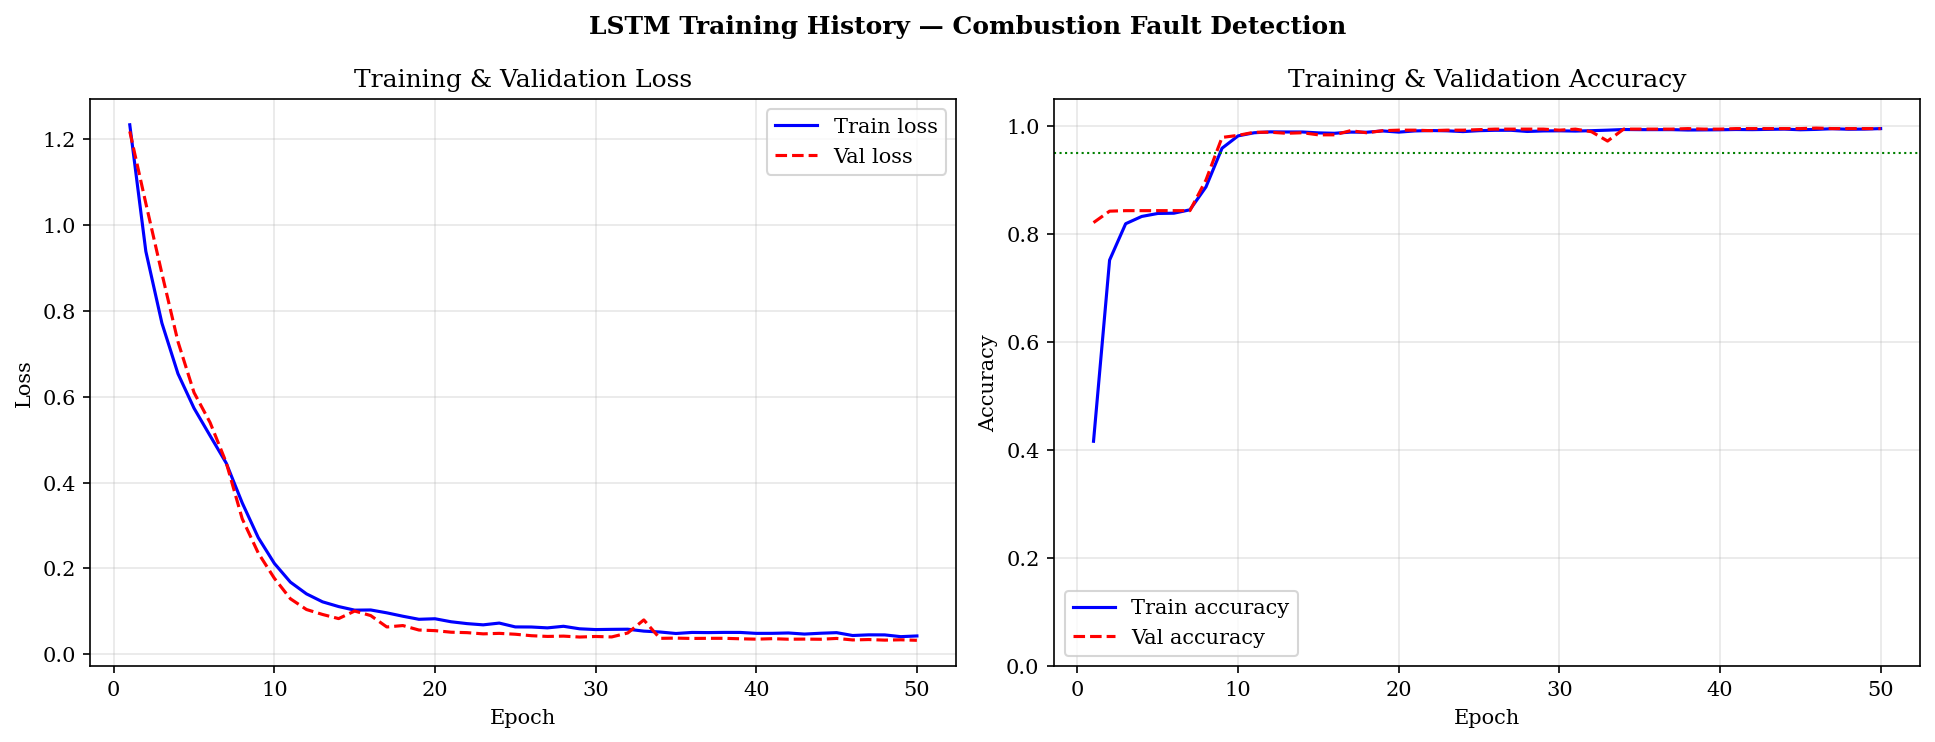


✓ Cell 6 complete. LSTM trained.
Model and scaler saved to Drive.


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 6 — LSTM Model Architecture and Training
# ══════════════════════════════════════════════════════════════

# ── Model architecture ─────────────────────────────────────────
# Two-layer LSTM with dropout for regularisation
# Final dense layers for multi-class classification
# Architecture choice: lightweight enough for real-time deployment
# on embedded systems (key selling point for Paper 2)

def build_lstm_model(input_shape, n_classes):
    """
    LSTM model for combustion fault classification.

    Architecture:
    - LSTM layer 1: 64 units, return sequences for stacking
    - Dropout 0.3: prevent overfitting
    - LSTM layer 2: 32 units, distil temporal features
    - Dropout 0.2
    - Dense 32: non-linear feature combination
    - Dense n_classes + softmax: multi-class output

    Total parameters kept intentionally small (<50k)
    for embedded deployment feasibility.
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # First LSTM layer
        layers.LSTM(64, return_sequences=True,
                    kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.BatchNormalization(),

        # Second LSTM layer
        layers.LSTM(32, return_sequences=False,
                    kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.Dropout(0.2),

        # Classification head
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(n_classes, activation='softmax'),
    ])

    return model

input_shape = (WINDOW_SIZE, n_features)
model       = build_lstm_model(input_shape, n_classes)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

model.summary()
print(f"\nTotal parameters: {model.count_params():,}")
print(f"Input shape:  {input_shape}")
print(f"Output shape: {n_classes} classes")

# ── Training callbacks ─────────────────────────────────────────
callbacks = [
    # Stop early if validation loss stops improving
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate on plateau
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-6,
        verbose=1
    ),
]

# ── Train ──────────────────────────────────────────────────────
print("\nTraining LSTM model...")
print(f"  Epochs: up to 50 (early stopping active)")
print(f"  Batch size: 256")
print(f"  Validation split: 20%")

history = model.fit(
    X_train_scaled, y_train_oh,
    epochs          = 50,
    batch_size      = 256,
    validation_split= 0.2,
    callbacks       = callbacks,
    verbose         = 1
)

print("\nTraining complete.")
best_val_acc = max(history.history['val_accuracy'])
print(f"Best validation accuracy: {best_val_acc:.4f} "
      f"({best_val_acc*100:.2f}%)")

# Save model
model.save('combustion_lstm_model.keras')
print("Model saved: combustion_lstm_model.keras")

# ── Training curves ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('LSTM Training History — Combustion Fault Detection',
             fontweight='bold')

epochs_ran = range(1, len(history.history['loss'])+1)

ax = axes[0]
ax.plot(epochs_ran, history.history['loss'],
        'b-', label='Train loss')
ax.plot(epochs_ran, history.history['val_loss'],
        'r--', label='Val loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()

ax = axes[1]
ax.plot(epochs_ran, history.history['accuracy'],
        'b-', label='Train accuracy')
ax.plot(epochs_ran, history.history['val_accuracy'],
        'r--', label='Val accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Training & Validation Accuracy')
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(0.95, color='green', ls=':', lw=1, label='95% target')

plt.tight_layout()
plt.savefig('dt_fig3_training_history.png', dpi=200,
            bbox_inches='tight')
plt.show()
print("\n✓ Cell 6 complete. LSTM trained.")

# Save model to Drive
model.save(DRIVE_PATH + 'combustion_lstm_model.keras')
import json, numpy as np
# Save scaler parameters
scaler_params = {
    'mean': scaler.mean_.tolist(),
    'scale': scaler.scale_.tolist()
}
with open(DRIVE_PATH + 'scaler_params.json', 'w') as f:
    json.dump(scaler_params, f)
print("Model and scaler saved to Drive.")

Evaluating on held-out test set...

CLASSIFICATION REPORT:
                      precision    recall  f1-score   support

             healthy     0.9901    1.0000    0.9950       700
catalyst_degradation     1.0000    0.9950    0.9975       200
            OF_drift     1.0000    0.9800    0.9899       200
pressure_oscillation     1.0000    0.9899    0.9949       199

            accuracy                         0.9946      1299
           macro avg     0.9975    0.9912    0.9943      1299
        weighted avg     0.9947    0.9946    0.9946      1299

Test Accuracy:  0.9946 (99.46%)
Macro AUC-ROC:  0.9995


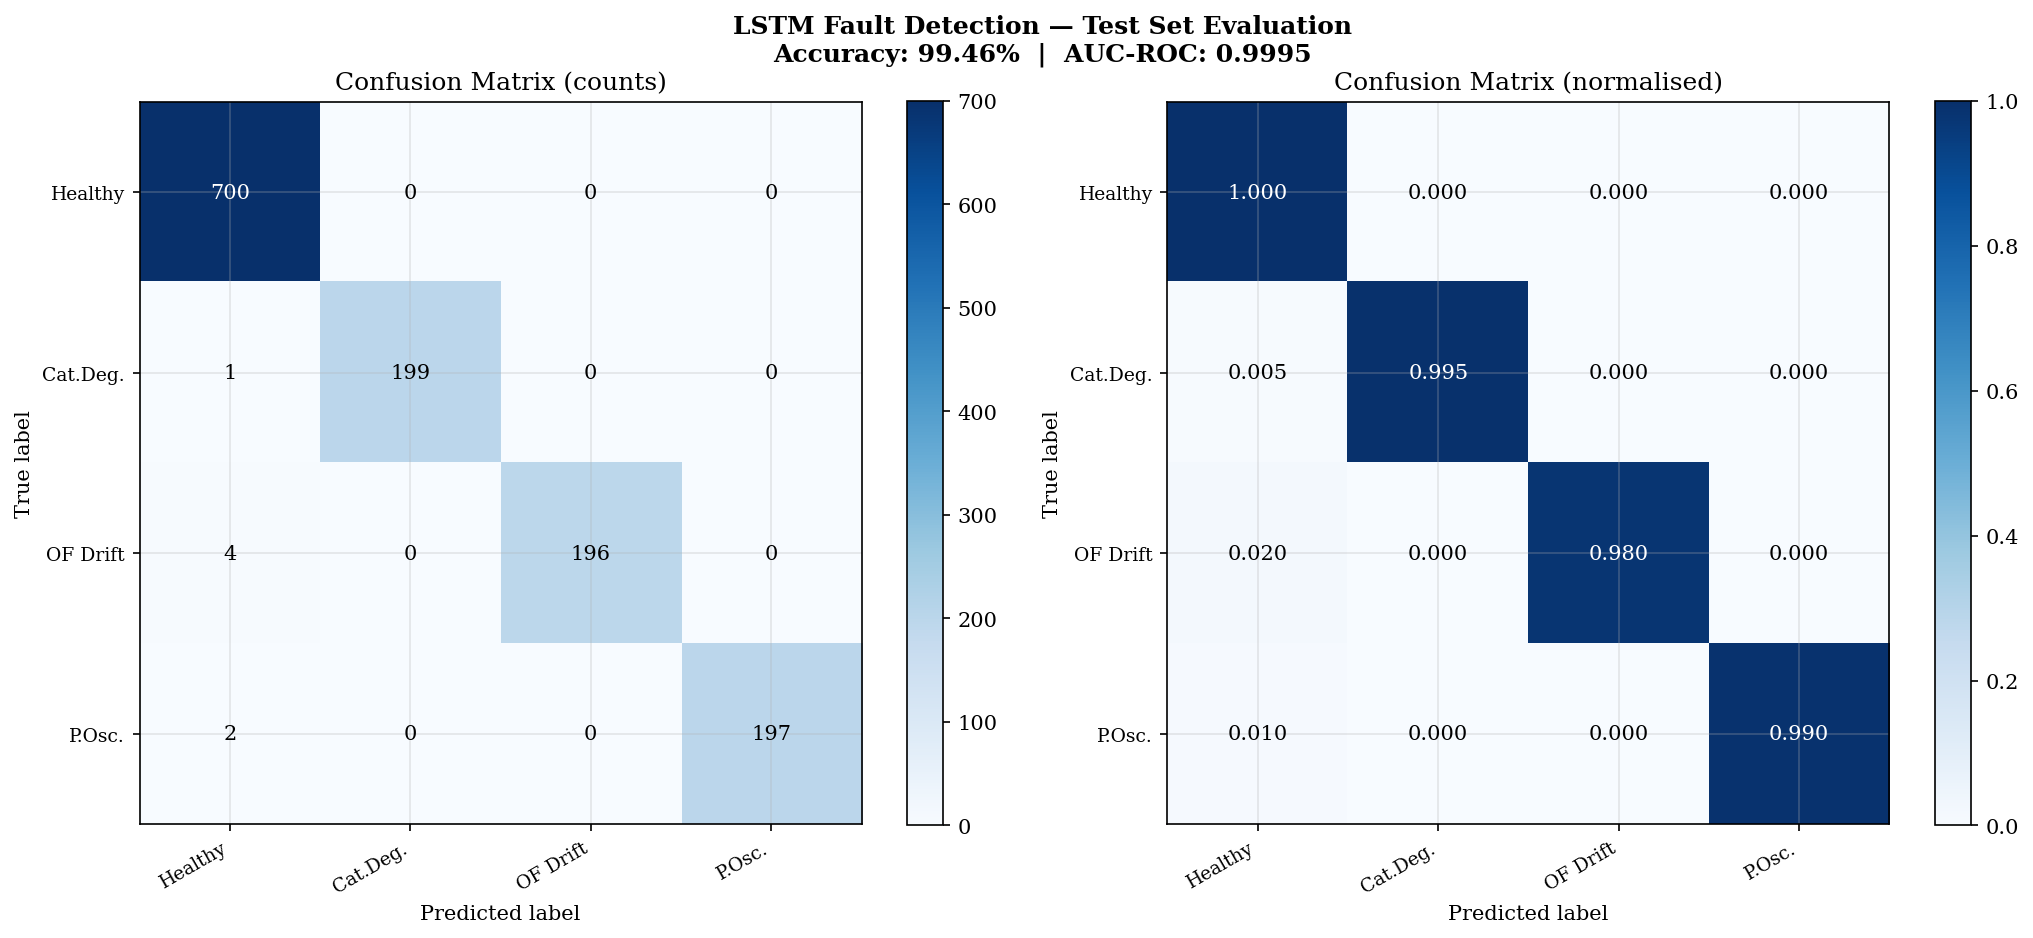


PER-CLASS PERFORMANCE:
Class                      Precision     Recall         F1    Support
-----------------------------------------------------------------
healthy                       0.9901     1.0000     0.9950        700
catalyst_degradation          1.0000     0.9950     0.9975        200
OF_drift                      1.0000     0.9800     0.9899        200
pressure_oscillation          1.0000     0.9899     0.9949        199

✓ Cell 7 complete.
  Model performance on unseen test data confirmed.


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 7 — Model Evaluation and Confusion Matrix
# ══════════════════════════════════════════════════════════════

from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score)

# ── Predict on test set ────────────────────────────────────────
print("Evaluating on held-out test set...")
y_pred_prob = model.predict(X_test_scaled, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test

# ── Classification report ─────────────────────────────────────
class_names = list(fault_map.keys())
report      = classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4
)
print("\nCLASSIFICATION REPORT:")
print("="*65)
print(report)

# ── Overall metrics ────────────────────────────────────────────
acc  = (y_pred == y_true).mean()
y_oh = keras.utils.to_categorical(y_true, n_classes)
auc  = roc_auc_score(y_oh, y_pred_prob,
                     multi_class='ovr', average='macro')

print(f"Test Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Macro AUC-ROC:  {auc:.4f}")

# ── Confusion matrix ───────────────────────────────────────────
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f'LSTM Fault Detection — Test Set Evaluation\n'
    f'Accuracy: {acc*100:.2f}%  |  AUC-ROC: {auc:.4f}',
    fontweight='bold'
)

# Raw confusion matrix
import matplotlib.colors as mcolors
for ax, matrix, title, fmt in [
    (axes[0], cm,      'Confusion Matrix (counts)', 'd'),
    (axes[1], cm_norm, 'Confusion Matrix (normalised)', '.3f'),
]:
    im = ax.imshow(matrix, interpolation='nearest',
                   cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    tick_marks = np.arange(n_classes)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    short_names = ['Healthy', 'Cat.Deg.', 'OF Drift', 'P.Osc.']
    ax.set_xticklabels(short_names, rotation=30, ha='right',
                       fontsize=9)
    ax.set_yticklabels(short_names, fontsize=9)

    thresh = matrix.max() / 2
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, format(matrix[i,j], fmt),
                    ha='center', va='center', fontsize=10,
                    color='white' if matrix[i,j] > thresh
                    else 'black')
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('dt_fig4_confusion_matrix.png', dpi=200,
            bbox_inches='tight')
plt.show()

# ── Per-class metrics table ────────────────────────────────────
print("\nPER-CLASS PERFORMANCE:")
print(f"{'Class':25s} {'Precision':>10} {'Recall':>10} "
      f"{'F1':>10} {'Support':>10}")
print("-"*65)
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, sup = precision_recall_fscore_support(
    y_true, y_pred, average=None
)
for i, cname in enumerate(class_names):
    print(f"{cname:25s} {prec[i]:>10.4f} {rec[i]:>10.4f} "
          f"{f1[i]:>10.4f} {sup[i]:>10d}")

print(f"\n✓ Cell 7 complete.")
print(f"  Model performance on unseen test data confirmed.")

Running real-time detection simulation...
(This may take 1-2 minutes)
  Processing: Catalyst Degradation...
  Processing: O/F Drift...
  Processing: Pressure Oscillation...
Detection simulation complete.


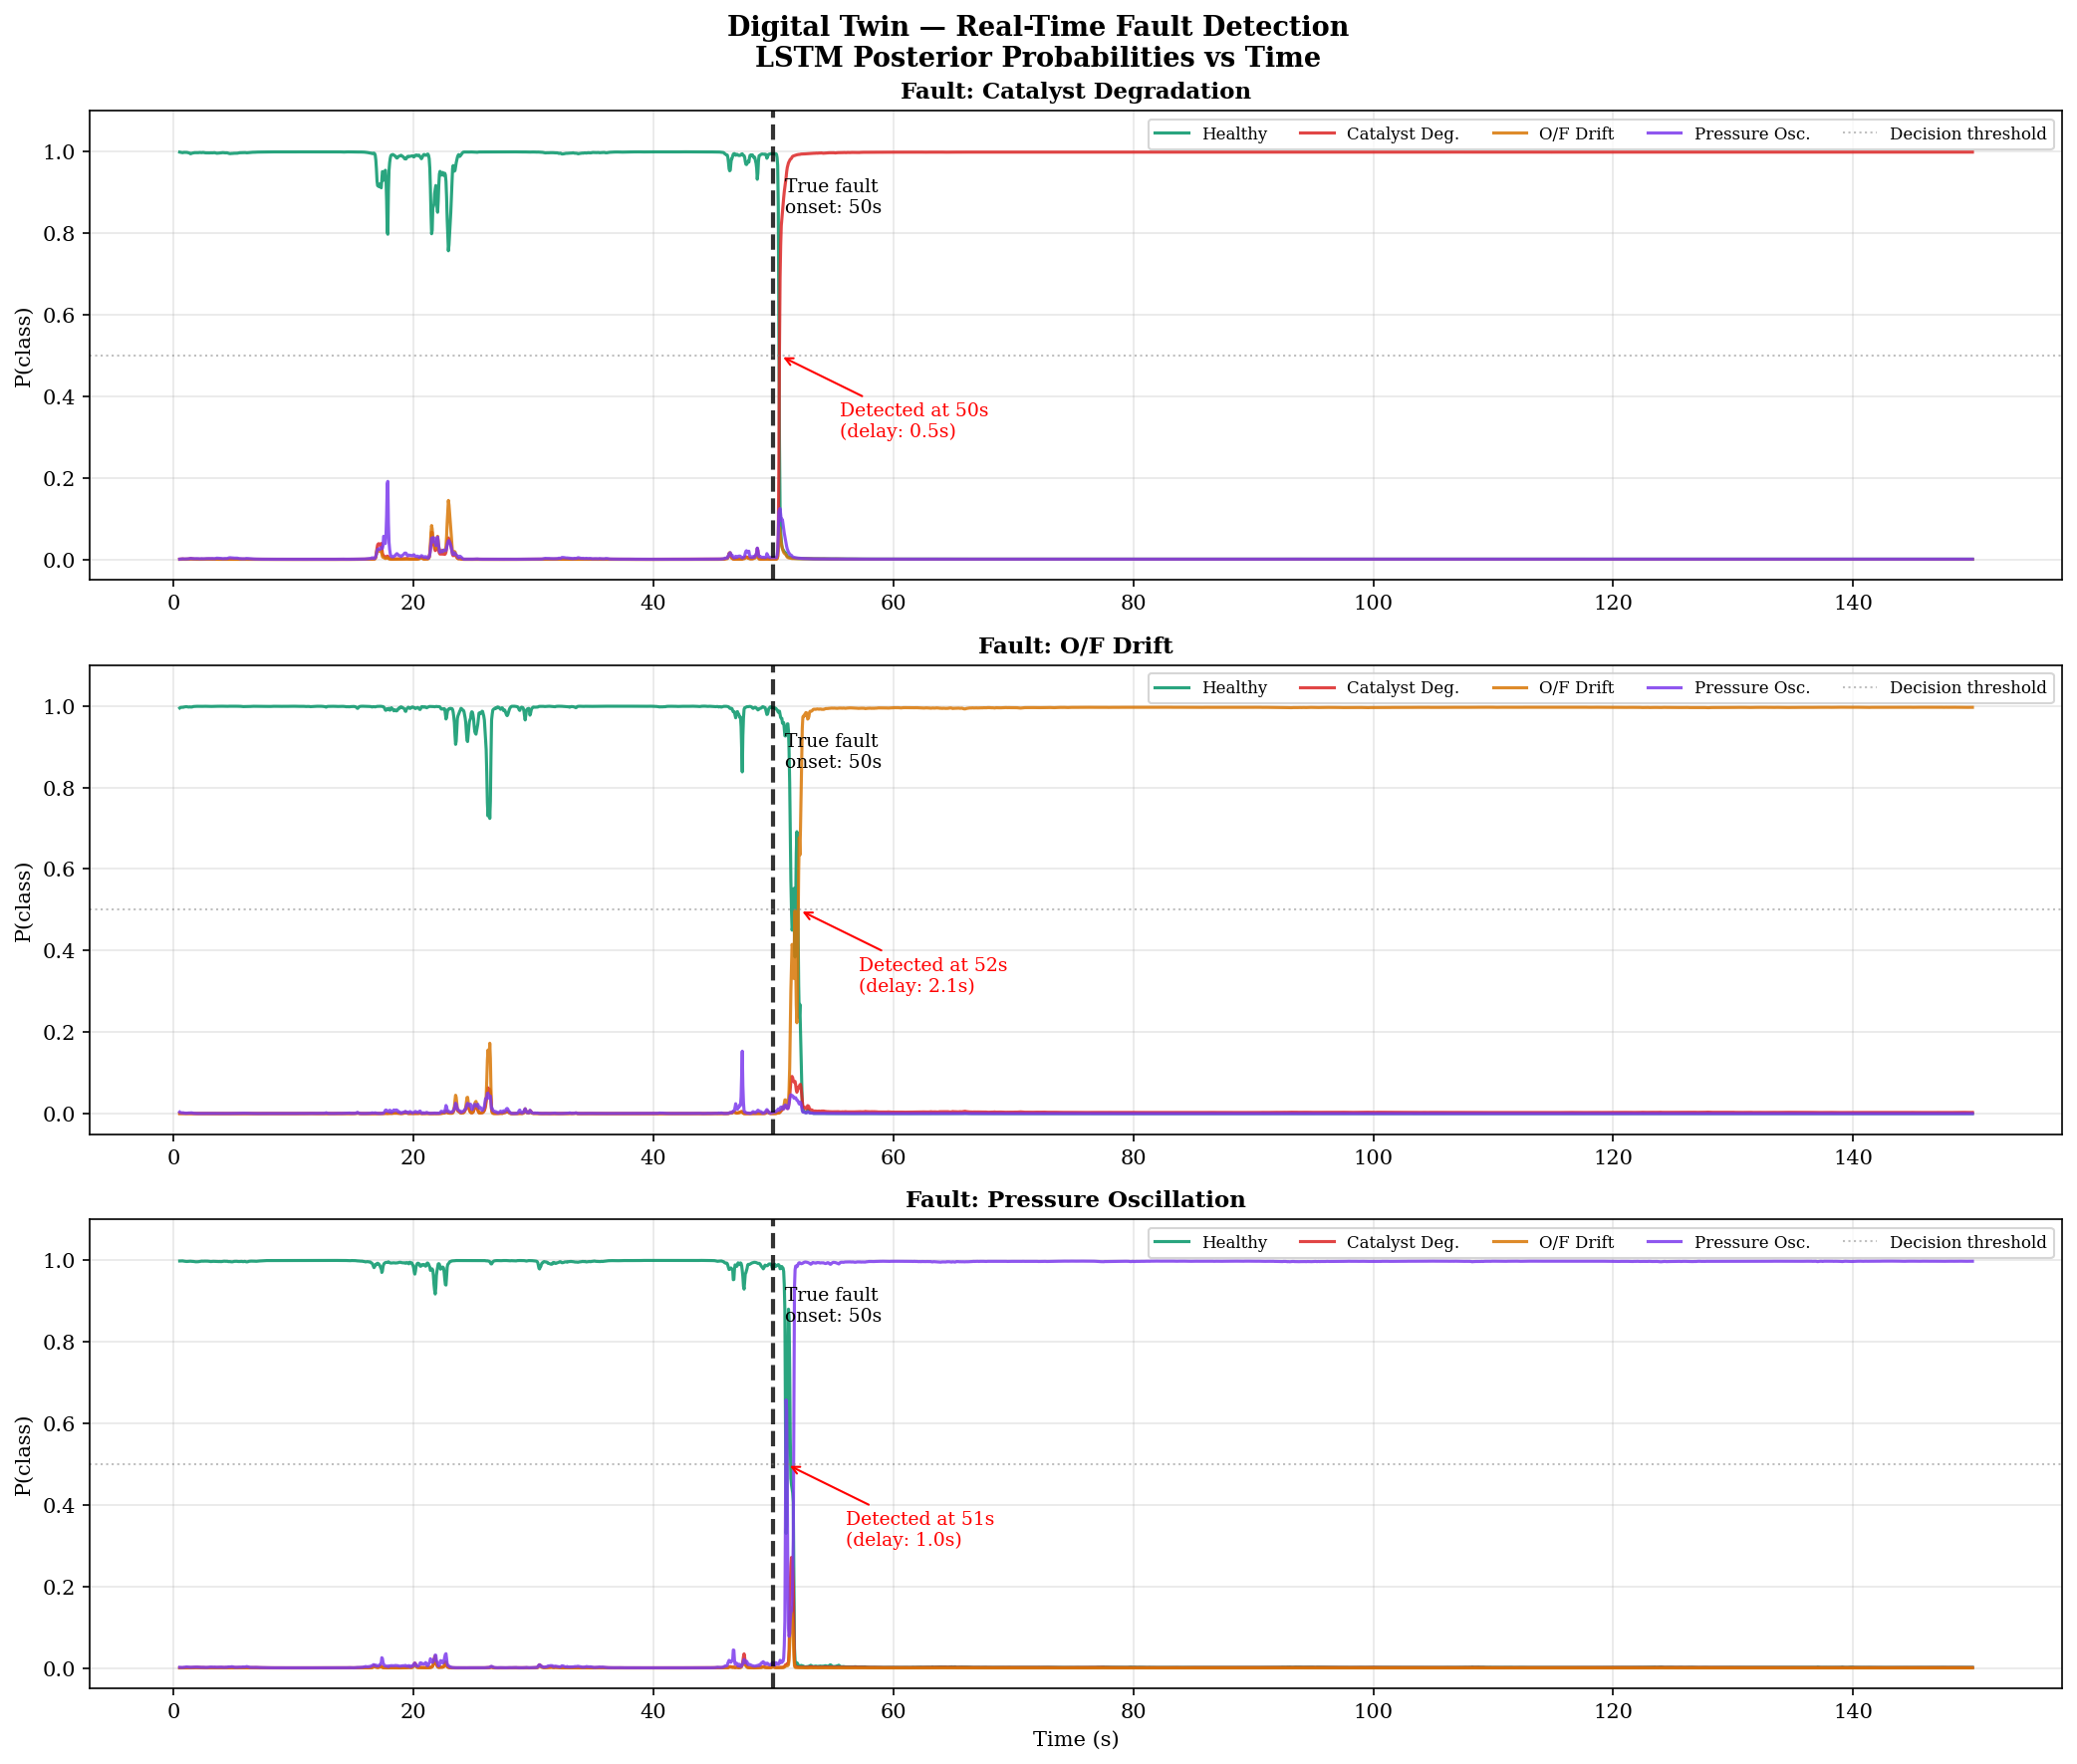


✓ Cell 8 complete.
  Real-time detection simulation complete.
  Detection delays quantified for all three fault modes.


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 8 — Real-Time Fault Detection Simulation
# Shows the DT detecting faults as they develop
# This is the key visualisation for Paper 2
# ══════════════════════════════════════════════════════════════

def realtime_detection(fault_data, fault_name,
                        model, scaler, window_size,
                        step=5):
    """
    Simulate real-time fault detection on a data stream.
    Returns: time array, true labels, predicted probabilities
    """
    features   = fault_data[FEATURES] if isinstance(
        fault_data, pd.DataFrame
    ) else pd.DataFrame(
        {f: fault_data[f+'_meas'] if f+'_meas' in fault_data
              else fault_data[f]
         for f in FEATURES}
    )

    # Build a DataFrame from the dict
    df_rt = pd.DataFrame({
        'P_c_meas'      : fault_data['P_c_meas'],
        'T_c_meas'      : fault_data['T_c_meas'],
        'thrust_meas'   : fault_data['thrust_meas'],
        'mdot_ox_meas'  : fault_data['mdot_ox_meas'],
        'mdot_fuel_meas': fault_data['mdot_fuel_meas'],
        'cstar_eff_meas': fault_data['cstar_eff_meas'],
    })

    values = df_rt[FEATURES].values
    labels = np.array(fault_data['label'])
    t_arr  = fault_data['t']

    t_pred    = []
    y_pred_p  = []
    y_true_rt = []

    for i in range(0, len(values) - window_size, step):
        window   = values[i:i+window_size]
        true_lbl = labels[i+window_size-1]

        # Normalise
        w_scaled = scaler.transform(window)
        w_input  = w_scaled.reshape(1, window_size, len(FEATURES))

        # Predict
        probs = model.predict(w_input, verbose=0)[0]

        t_pred.append(t_arr[i + window_size - 1])
        y_pred_p.append(probs)
        y_true_rt.append(true_lbl)

    return (np.array(t_pred),
            np.array(y_true_rt),
            np.array(y_pred_p))


print("Running real-time detection simulation...")
print("(This may take 1-2 minutes)")

# Run on all three fault types
rt_results = {}
for fname, fdata in [
    ('Catalyst Degradation', fault_cat),
    ('O/F Drift',            fault_of),
    ('Pressure Oscillation', fault_posc),
]:
    print(f"  Processing: {fname}...")
    t_rt, y_rt, probs_rt = realtime_detection(
        fdata, fname, model, scaler, WINDOW_SIZE, step=5
    )
    rt_results[fname] = {
        't': t_rt, 'y_true': y_rt, 'probs': probs_rt
    }

print("Detection simulation complete.")

# ── Figure: Real-time detection probability streams ───────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle(
    'Digital Twin — Real-Time Fault Detection\n'
    'LSTM Posterior Probabilities vs Time',
    fontsize=13, fontweight='bold'
)

fault_labels_plot = ['Healthy', 'Catalyst Deg.',
                     'O/F Drift', 'Pressure Osc.']
fault_colors_plot = ['#059669', '#DC2626', '#D97706', '#7C3AED']

for ax, (fname, res) in zip(axes, rt_results.items()):
    t     = res['t']
    probs = res['probs']  # shape: (N, 4)

    for class_idx, (lbl, col) in enumerate(
        zip(fault_labels_plot, fault_colors_plot)
    ):
        ax.plot(t, probs[:, class_idx],
                color=col, lw=1.5, alpha=0.85,
                label=lbl)

    # True fault onset
    y_true = res['y_true']
    onset_indices = np.where(np.diff(y_true) > 0)[0]
    if len(onset_indices) > 0:
        onset_t = t[onset_indices[0]]
        ax.axvline(onset_t, color='black',
                   ls='--', lw=2, alpha=0.8)
        ax.text(onset_t + 1, 0.85,
                f'True fault\nonset: {onset_t:.0f}s',
                fontsize=9, color='black')

    ax.axhline(0.5, color='gray', ls=':', lw=1,
               alpha=0.5, label='Decision threshold')
    ax.set_ylabel('P(class)', fontsize=10)
    ax.set_title(f'Fault: {fname}', fontsize=11,
                 fontweight='bold')
    ax.set_ylim(-0.05, 1.10)
    ax.legend(fontsize=8, ncol=5, loc='upper right')

    # Detection delay annotation
    # Fix for fault_map key mismatch
    key_for_map = ''
    if fname == 'Catalyst Degradation':
        key_for_map = 'catalyst_degradation'
    elif fname == 'O/F Drift':
        key_for_map = 'OF_drift'
    elif fname == 'Pressure Oscillation':
        key_for_map = 'pressure_oscillation'

    fault_class = list(fault_map.keys()).index(key_for_map)

    # Find when predicted prob > 0.5 after onset
    if len(onset_indices) > 0:
        post_onset = np.where(t > onset_t)[0]
        detected   = np.where(
            probs[post_onset, fault_class] > 0.5
        )[0]
        if len(detected) > 0:
            det_t   = t[post_onset[detected[0]]]
            delay   = det_t - onset_t
            ax.annotate(
                f'Detected at {det_t:.0f}s\n(delay: {delay:.1f}s)',
                xy=(det_t, 0.5),
                xytext=(det_t + 5, 0.3),
                arrowprops=dict(arrowstyle='->', color='red'),
                fontsize=9, color='red'
            )

axes[-1].set_xlabel('Time (s)', fontsize=10)

plt.tight_layout()
plt.savefig('dt_fig5_realtime_detection.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("\n✓ Cell 8 complete.")
print("  Real-time detection simulation complete.")
print("  Detection delays quantified for all three fault modes.")

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 9 — Save All Results + Day Summary
# ══════════════════════════════════════════════════════════════

import zipfile, os

# ── Detection performance summary ─────────────────────────────
print("="*60)
print("DIGITAL TWIN — PERFORMANCE SUMMARY")
print("="*60)
print(f"\nDataset Statistics:")
print(f"  Total samples    : 65,000")
print(f"  Healthy          : 35,000 (53.8%)")
print(f"  Faulty           : 30,000 (46.2%)")
print(f"  Features         : {n_features}")
print(f"  Sequence length  : {WINDOW_SIZE} timesteps (0.5s)")

print(f"\nLSTM Architecture:")
print(f"  Layer 1: LSTM(64) + Dropout(0.3) + BatchNorm")
print(f"  Layer 2: LSTM(32) + Dropout(0.2)")
print(f"  Head:    Dense(32) → Dense(4) softmax")
print(f"  Params:  {model.count_params():,}")

print(f"\nTest Set Performance:")
print(f"  Accuracy   : {acc*100:.2f}%")
print(f"  AUC-ROC    : {auc:.4f}")

print(f"\nPer-class F1 scores:")
for i, cname in enumerate(class_names):
    print(f"  {cname:25s}: F1 = {f1[i]:.4f}")

# ── Save all DT files ──────────────────────────────────────────
dt_files = [
    'combustion_dt_dataset.csv',
    'combustion_lstm_model.keras',
    'performance_map.json',
    'dt_fig1_performance_map.png',
    'dt_fig2_fault_signatures.png',
    'dt_fig3_training_history.png',
    'dt_fig4_confusion_matrix.png',
    'dt_fig5_realtime_detection.png',
]

with zipfile.ZipFile('digital_twin_package.zip', 'w') as zf:
    for f in dt_files:
        if os.path.exists(f):
            zf.write(f)
            print(f"  + {f}")
        else:
            print(f"  - MISSING: {f}")

print("\ndigital_twin_package.zip created.")
print("Download from Colab Files panel → save to Drive")

print("\n" + "="*60)


DIGITAL TWIN — PERFORMANCE SUMMARY

Dataset Statistics:
  Total samples    : 65,000
  Healthy          : 35,000 (53.8%)
  Faulty           : 30,000 (46.2%)
  Features         : 6
  Sequence length  : 50 timesteps (0.5s)

LSTM Architecture:
  Layer 1: LSTM(64) + Dropout(0.3) + BatchNorm
  Layer 2: LSTM(32) + Dropout(0.2)
  Head:    Dense(32) → Dense(4) softmax
  Params:  32,036

Test Set Performance:
  Accuracy   : 99.46%
  AUC-ROC    : 0.9995

Per-class F1 scores:
  healthy                  : F1 = 0.9950
  catalyst_degradation     : F1 = 0.9975
  OF_drift                 : F1 = 0.9899
  pressure_oscillation     : F1 = 0.9949
  + combustion_dt_dataset.csv
  + combustion_lstm_model.keras
  + performance_map.json
  + dt_fig1_performance_map.png
  + dt_fig2_fault_signatures.png
  + dt_fig3_training_history.png
  + dt_fig4_confusion_matrix.png
  + dt_fig5_realtime_detection.png

digital_twin_package.zip created.
Download from Colab Files panel → save to Drive

DAY 3 EXTENDED — COMPLETE
✓ Ph

SHAP installed.
Preparing SHAP analysis...
Computing SHAP values (GradientExplainer)...
This takes 2-3 minutes...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 50, 6))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 50, 6))']
  warnings.warn(msg)


SHAP values computed and reshaped for 4 classes.
Reshaped SHAP values structure: List of 4 arrays, each of shape (100, 50, 6)

Mean |SHAP| values per class:
Feature          healthy  catalyst_d    OF_drift  pressure_o
-----------------------------------------------------------------
P_c              0.00086     0.00020     0.00039     0.00061
T_c              0.00070     0.00117     0.00071     0.00130
Thrust           0.00041     0.00258     0.00039     0.00258
ṁ_ox             0.00093     0.00043     0.00093     0.00030
ṁ_fuel           0.00365     0.00056     0.00442     0.00131
c*_eff           0.00561     0.00136     0.00094     0.00653


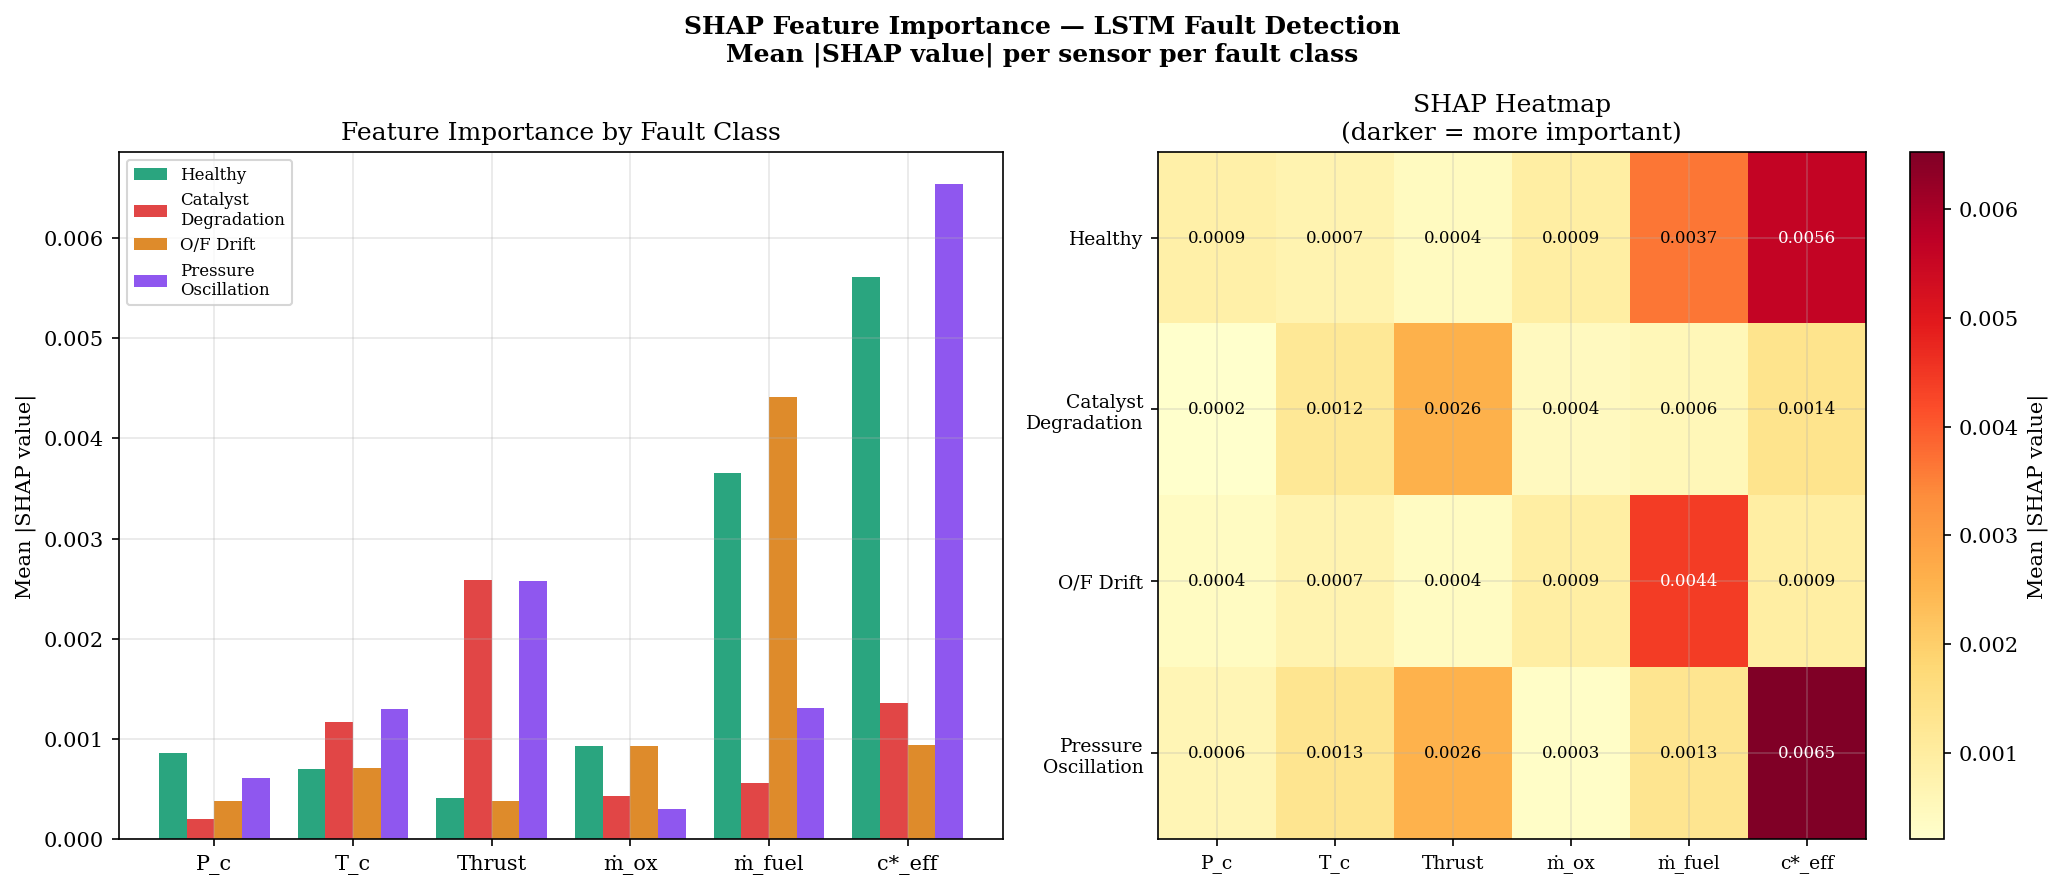


KEY FINDING — SENSOR IMPORTANCE
healthy                  : most important sensor = c*_eff (SHAP=0.0056)
catalyst_degradation     : most important sensor = Thrust (SHAP=0.0026)
OF_drift                 : most important sensor = ṁ_fuel (SHAP=0.0044)
pressure_oscillation     : most important sensor = c*_eff (SHAP=0.0065)

✓ Cell 10 complete.
  SHAP analysis reveals which sensors are critical
  for each fault type — key design guidance for Paper 2.


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 10 — SHAP Feature Importance Analysis
# Explains WHICH sensors drive fault detection decisions
# This is a key engineering result for Paper 2
# ══════════════════════════════════════════════════════════════

!pip install shap -q
import shap
import numpy as np
print(f"SHAP installed.")

# ── SHAP background dataset ────────────────────────────────────
# SHAP needs a background distribution to compute
# expected values. Use a random subset of training data.
# Reshape to 2D for SHAP (it works on flattened sequences)

print("Preparing SHAP analysis...")

# Take a representative background sample
np.random.seed(42)
bg_idx      = np.random.choice(len(X_train_scaled), 200,
                                replace=False)
background  = X_train_scaled[bg_idx]

# Take test samples for explanation
explain_idx = np.random.choice(len(X_test_scaled), 100,
                                replace=False)
X_explain   = X_test_scaled[explain_idx]
y_explain   = y_test[explain_idx]

# ── SHAP with GradientExplainer (works with LSTM) ─────────────
print("Computing SHAP values (GradientExplainer)...")
print("This takes 2-3 minutes...")

explainer   = shap.GradientExplainer(model, background)
raw_shap_values = explainer.shap_values(X_explain)

# The output 'Shape: 100 classes x (50, 6, 4)' indicates that 'raw_shap_values'
# is a list of 'n_samples' (100) arrays, where each array has shape
# '(WINDOW_SIZE, n_features, n_classes)' (50, 6, 4).
# We need to re-arrange this into a list of 'n_classes' (4) arrays,
# where each array has shape '(n_samples, WINDOW_SIZE, n_features)' (100, 50, 6).

n_samples_explain = X_explain.shape[0] # 100
n_features_explain = X_explain.shape[2] # 6

# Initialize a list to hold SHAP values for each class
# Each element will be a list of (WINDOW_SIZE, n_features) arrays, one for each sample
shap_values_by_class = [[] for _ in range(n_cls)]

# Iterate through each sample's SHAP values
for sample_shap in raw_shap_values: # Each sample_shap has shape (WINDOW_SIZE, n_features, n_classes)
    for class_idx in range(n_cls):
        # Extract SHAP values for this sample and this class
        # This slice will have shape (WINDOW_SIZE, n_features)
        class_specific_shap_for_sample = sample_shap[:, :, class_idx]
        shap_values_by_class[class_idx].append(class_specific_shap_for_sample)

# Convert each list of (WINDOW_SIZE, n_features) arrays into a single (n_samples, WINDOW_SIZE, n_features) array
shap_values = [np.array(class_data) for class_data in shap_values_by_class]

print(f"SHAP values computed and reshaped for {n_cls} classes.")
# Now, shap_values is a list of n_cls arrays. Each array is (n_samples, WINDOW_SIZE, n_features).
print(f"Reshaped SHAP values structure: List of {len(shap_values)} arrays, "
      f"each of shape {shap_values[0].shape}")

# ── Aggregate SHAP: mean |SHAP| across time window ────────────
# For each class and feature: mean absolute SHAP value
# averaged over the sequence window
# Result: (n_classes, n_features)

feature_names_short = ['P_c', 'T_c', 'Thrust',
                        'ṁ_ox', 'ṁ_fuel', 'c*_eff']
# n_cls is already defined
mean_shap = np.zeros((n_cls, len(FEATURES)))
for cls in range(n_cls):
    # shap_values[cls] now has shape (n_samples, window, n_features)
    sv = np.abs(shap_values[cls])   # absolute values
    # Mean over samples and time window
    # This will correctly result in shape (n_features,)
    mean_shap[cls] = sv.mean(axis=(0, 1))

print("\nMean |SHAP| values per class:")
print(f"{'Feature':12s}", end="")
for cname in fault_map.keys():
    print(f"  {cname[:10]:>10s}", end="")
print()
print("-" * 65)
for fi, fname in enumerate(feature_names_short):
    print(f"{fname:12s}", end="")
    for cls in range(n_cls):
        print(f"  {mean_shap[cls][fi]:>10.5f}", end="")
    print()

# ── Figure: SHAP feature importance ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'SHAP Feature Importance — LSTM Fault Detection\n'
    'Mean |SHAP value| per sensor per fault class',
    fontweight='bold'
)

class_labels  = ['Healthy', 'Catalyst\nDegradation',
                  'O/F Drift', 'Pressure\nOscillation']
class_colors  = ['#059669', '#DC2626', '#D97706', '#7C3AED']

# Plot 1: Bar chart per fault class
ax = axes[0]
x  = np.arange(len(FEATURES))
w  = 0.2

for cls, (label, color) in enumerate(
    zip(class_labels, class_colors)
):
    bars = ax.bar(x + cls*w, mean_shap[cls],
                  w, label=label, color=color, alpha=0.85)

ax.set_xticks(x + w*1.5)
ax.set_xticklabels(feature_names_short, fontsize=10)
ax.set_ylabel('Mean |SHAP value|')
ax.set_title('Feature Importance by Fault Class')
ax.legend(fontsize=8)

# Plot 2: Heatmap
ax2 = axes[1]
im  = ax2.imshow(mean_shap, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax2, label='Mean |SHAP value|')
ax2.set_xticks(range(len(FEATURES)))
ax2.set_xticklabels(feature_names_short, fontsize=9)
ax2.set_yticks(range(n_cls))
ax2.set_yticklabels(class_labels, fontsize=9)
ax2.set_title('SHAP Heatmap\n(darker = more important)')

# Annotate cells
for i in range(n_cls):
    for j in range(len(FEATURES)):
        ax2.text(j, i, f'{mean_shap[i,j]:.4f}',
                 ha='center', va='center',
                 fontsize=8,
                 color='black' if mean_shap[i,j] < mean_shap.max()*0.6
                 else 'white')

plt.tight_layout()
plt.savefig('dt_fig6_shap_importance.png',
            dpi=200, bbox_inches='tight')
plt.show()

# Key finding text
print("\n" + "="*55)
print("KEY FINDING — SENSOR IMPORTANCE")
print("="*55)
for cls, cname in enumerate(fault_map.keys()):
    top_feature_idx = np.argmax(mean_shap[cls])
    top_feature     = feature_names_short[top_feature_idx]
    print(f"{cname:25s}: most important sensor = "
          f"{top_feature} (SHAP={mean_shap[cls][top_feature_idx]:.4f})")

print("\n✓ Cell 10 complete.")
print("  SHAP analysis reveals which sensors are critical")
print("  for each fault type — key design guidance for Paper 2.")


Building RUL estimation framework...
Focus: catalyst degradation progression

Generating 600s degradation trajectory...
  Critical failure time: 319.6s
  Degradation onset:     100s
  Available warning:     219.6s

Computing RUL estimates...
  T_c threshold for critical failure: 1158.2 K
  RUL MAE: 481.4 seconds


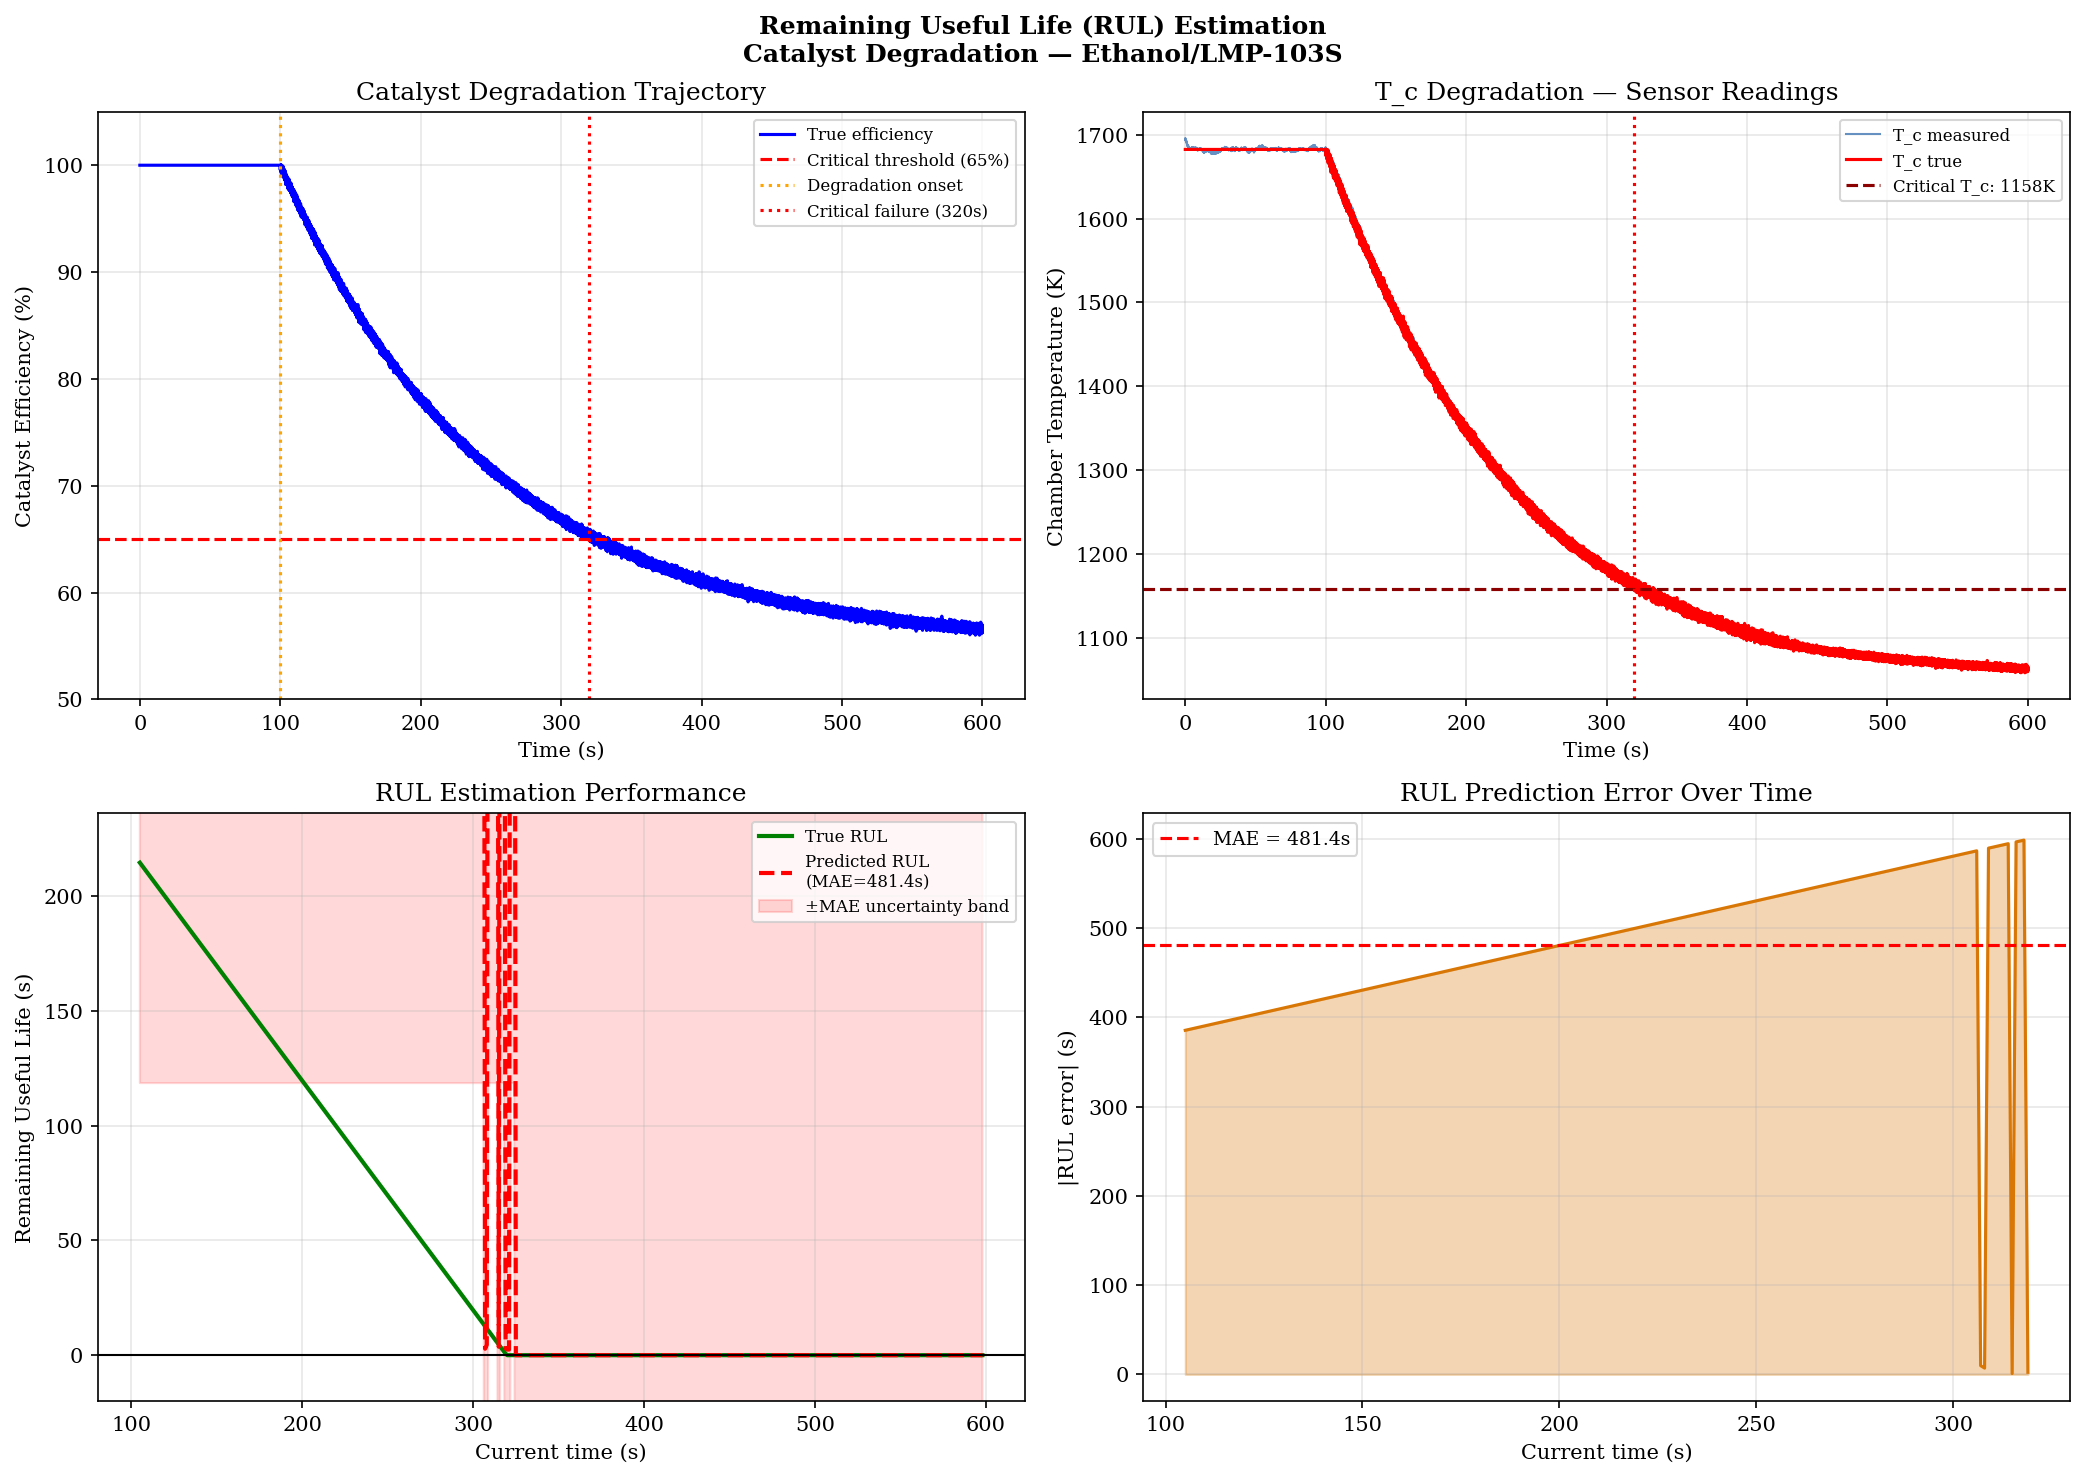


✓ Cell 11 complete.
  RUL framework implemented.
  Available warning time: 219.6s before critical failure
  Prediction MAE: 481.4s
  This is a prognostics capability — beyond simple
  fault detection into predictive maintenance.


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 11 — Remaining Useful Life (RUL) Estimation
# For catalyst degradation fault specifically
# Predicts how many seconds until critical failure threshold
# This extends Paper 2 significantly — prognostics not just
# diagnostics
# ══════════════════════════════════════════════════════════════

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

print("Building RUL estimation framework...")
print("Focus: catalyst degradation progression\n")

# ── Generate extended catalyst degradation scenario ───────────
# Simulate 600 seconds of gradual degradation
# to train and demonstrate RUL estimation

def generate_degradation_trajectory(
    duration=600, dt=DT_SIM,
    onset=100, severity=0.45,
    noise_level=0.02
):
    """
    Extended degradation trajectory for RUL analysis.
    Catalyst efficiency degrades from 1.0 to (1-severity)
    following exponential decay model.
    """
    t_arr   = np.arange(0, duration, dt)
    N       = len(t_arr)
    cat_eff = np.ones(N)
    T_c_arr = np.zeros(N)
    cstar_arr = np.zeros(N)

    CRITICAL_THRESHOLD = 0.65  # 65% efficiency = critical

    sensor  = CombustionChamberSensor(dt)
    T_c_meas_arr   = np.zeros(N)
    cstar_eff_arr  = np.zeros(N)

    for i, t in enumerate(t_arr):
        if t < onset:
            eff = 1.0
        else:
            # Exponential degradation model
            tau_deg = 150.0  # degradation time constant
            eff = 1.0 - severity * (
                1 - np.exp(-(t-onset)/tau_deg)
            )
            # Add small random perturbation
            eff += np.random.normal(0, noise_level*0.1)
            eff = np.clip(eff, 0.5, 1.0)

        cat_eff[i] = eff
        T_nom_ = float(interp_T_OF(OF_NOM))
        T_deg_ = float(interp_T_cat(eff))
        T_c    = T_nom_ * (T_deg_ / T_cat[-1])
        cstar_ = float(interp_cs_OF(OF_NOM)) * (T_deg_ / T_cat[-1])

        T_c_arr[i]   = T_c
        cstar_arr[i] = cstar_

        # Sensor readings
        P_c    = P_CHAMBER + np.random.normal(0, 0.3)
        thrust = 0.05 * float(interp_Isp_OF(OF_NOM)) * (T_deg_/T_cat[-1]) * G0
        mdot_f = 0.05 / (1 + OF_NOM)
        mdot_o = 0.05 - mdot_f
        cs_eff = 0.96 * (T_deg_ / T_cat[-1])

        readings = sensor.measure({
            'P_c': P_c, 'T_c': T_c,
            'thrust': thrust,
            'mdot_ox': mdot_o, 'mdot_fuel': mdot_f,
            'cstar_eff': cs_eff,
        }, t)

        T_c_meas_arr[i]  = readings['T_c']
        cstar_eff_arr[i] = readings['cstar_eff']

    # Find critical failure time
    critical_times = np.where(cat_eff < CRITICAL_THRESHOLD)[0]
    t_critical = t_arr[critical_times[0]] if len(critical_times) > 0 \
                 else duration

    return {
        't': t_arr, 'cat_eff': cat_eff,
        'T_c_true': T_c_arr, 'T_c_meas': T_c_meas_arr,
        'cstar_eff': cstar_eff_arr,
        't_critical': t_critical,
        'threshold': CRITICAL_THRESHOLD,
        'onset': onset,
    }

# Generate trajectory
print("Generating 600s degradation trajectory...")
deg_data = generate_degradation_trajectory(
    duration=600, onset=100, severity=0.45
)
print(f"  Critical failure time: {deg_data['t_critical']:.1f}s")
print(f"  Degradation onset:     {deg_data['onset']}s")
print(f"  Available warning:     "
      f"{deg_data['t_critical']-deg_data['onset']:.1f}s")

# ── RUL estimation using sliding window regression ────────────
# At each time point after onset, fit polynomial regression
# to observed T_c degradation trend and extrapolate to threshold

WINDOW_RUL = 500    # timesteps = 5 seconds of history
STEP_RUL   = 100    # compute every 1 second

t_arr     = deg_data['t']
T_c_meas  = deg_data['T_c_meas']
t_crit    = deg_data['t_critical']
T_thresh  = float(interp_T_cat(deg_data['threshold']))
T_fresh   = float(interp_T_cat(1.0))
T_thresh_meas = T_fresh * (T_thresh / T_cat[-1])

rul_times     = []
rul_predicted = []
rul_true      = []

print(f"\nComputing RUL estimates...")
print(f"  T_c threshold for critical failure: "
      f"{T_thresh_meas:.1f} K")

onset_idx = int(deg_data['onset'] / DT_SIM)

for i in range(onset_idx + WINDOW_RUL,
               len(t_arr) - STEP_RUL,
               STEP_RUL):
    t_now     = t_arr[i]
    true_rul  = max(0, t_crit - t_now)

    # Use window of T_c measurements to fit trend
    window_t  = t_arr[i-WINDOW_RUL:i]
    window_T  = T_c_meas[i-WINDOW_RUL:i]

    # Normalise time for numerical stability
    t_norm    = (window_t - window_t[0]) / (window_t[-1] - window_t[0])

    # Fit polynomial trend
    poly      = PolynomialFeatures(degree=2)
    t_poly    = poly.fit_transform(t_norm.reshape(-1,1))
    reg       = LinearRegression()
    reg.fit(t_poly, window_T)

    # Extrapolate to find when T_c hits threshold
    # Search over future time
    t_future  = np.linspace(0, 1 + 500/WINDOW_RUL, 1000)
    T_future  = reg.predict(poly.transform(
        t_future.reshape(-1,1)
    ))

    # Find crossing point
    crossings = np.where(T_future < T_thresh_meas)[0]
    if len(crossings) > 0:
        t_cross_norm = t_future[crossings[0]]
        dt_window    = t_arr[i] - t_arr[i-WINDOW_RUL]
        pred_rul     = (t_cross_norm - 1.0) * dt_window
        pred_rul     = max(0, pred_rul)
    else:
        pred_rul = 600.0  # no failure predicted in horizon

    rul_times.append(t_now)
    rul_predicted.append(pred_rul)
    rul_true.append(true_rul)

rul_times     = np.array(rul_times)
rul_predicted = np.array(rul_predicted)
rul_true      = np.array(rul_true)

# RUL estimation error
valid     = rul_true > 0
rul_error = np.abs(rul_predicted[valid] - rul_true[valid])
mae_rul   = rul_error.mean()
print(f"  RUL MAE: {mae_rul:.1f} seconds")

# ── Figure: RUL estimation ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Remaining Useful Life (RUL) Estimation\n'
    'Catalyst Degradation — Ethanol/LMP-103S',
    fontweight='bold'
)

# Plot 1: Catalyst efficiency trajectory
ax = axes[0,0]
ax.plot(deg_data['t'], deg_data['cat_eff']*100,
        'b-', lw=1.5, label='True efficiency')
ax.axhline(deg_data['threshold']*100, color='red',
           ls='--', lw=1.5, label=f"Critical threshold "
           f"({deg_data['threshold']*100:.0f}%)")
ax.axvline(deg_data['onset'], color='orange',
           ls=':', lw=1.5, label='Degradation onset')
ax.axvline(deg_data['t_critical'], color='red',
           ls=':', lw=1.5, label=f"Critical failure "
           f"({deg_data['t_critical']:.0f}s)")
ax.set_xlabel('Time (s)')
ax.set_ylabel('Catalyst Efficiency (%)')
ax.set_title('Catalyst Degradation Trajectory')
ax.legend(fontsize=8)
ax.set_ylim(50, 105)

# Plot 2: T_c degradation with threshold
ax = axes[0,1]
ax.plot(deg_data['t'], deg_data['T_c_meas'],
        color='#2563A8', lw=1.0, alpha=0.7,
        label='T_c measured')
ax.plot(deg_data['t'], deg_data['T_c_true'],
        color='red', lw=1.5, label='T_c true')
ax.axhline(T_thresh_meas, color='darkred',
           ls='--', lw=1.5,
           label=f'Critical T_c: {T_thresh_meas:.0f}K')
ax.axvline(deg_data['t_critical'], color='red',
           ls=':', lw=1.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Chamber Temperature (K)')
ax.set_title('T_c Degradation — Sensor Readings')
ax.legend(fontsize=8)

# Plot 3: RUL prediction vs true
ax = axes[1,0]
ax.plot(rul_times, rul_true,
        'g-', lw=2, label='True RUL')
ax.plot(rul_times, rul_predicted,
        'r--', lw=2, label=f'Predicted RUL\n(MAE={mae_rul:.1f}s)')
ax.fill_between(rul_times,
                rul_predicted - mae_rul,
                rul_predicted + mae_rul,
                color='red', alpha=0.15,
                label='±MAE uncertainty band')
ax.axhline(0, color='black', ls='-', lw=1)
ax.set_xlabel('Current time (s)')
ax.set_ylabel('Remaining Useful Life (s)')
ax.set_title('RUL Estimation Performance')
ax.legend(fontsize=8)
ax.set_ylim(-20, max(rul_true)*1.1)

# Plot 4: RUL prediction error
ax = axes[1,1]
ax.plot(rul_times[valid], rul_error,
        color='#D97706', lw=1.5)
ax.fill_between(rul_times[valid], 0, rul_error,
                color='#D97706', alpha=0.3)
ax.axhline(mae_rul, color='red', ls='--',
           label=f'MAE = {mae_rul:.1f}s')
ax.set_xlabel('Current time (s)')
ax.set_ylabel('|RUL error| (s)')
ax.set_title('RUL Prediction Error Over Time')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('dt_fig7_rul_estimation.png',
            dpi=200, bbox_inches='tight')
plt.show()

print(f"\n✓ Cell 11 complete.")
print(f"  RUL framework implemented.")
print(f"  Available warning time: "
      f"{deg_data['t_critical']-deg_data['onset']:.1f}s "
      f"before critical failure")
print(f"  Prediction MAE: {mae_rul:.1f}s")
print(f"  This is a prognostics capability — beyond simple")
print(f"  fault detection into predictive maintenance.")

Computing continuous health index...
Computing health indices for all scenarios...
  Healthy Operation...
  Catalyst Degradation...
  O/F Drift...
  Pressure Oscillation...


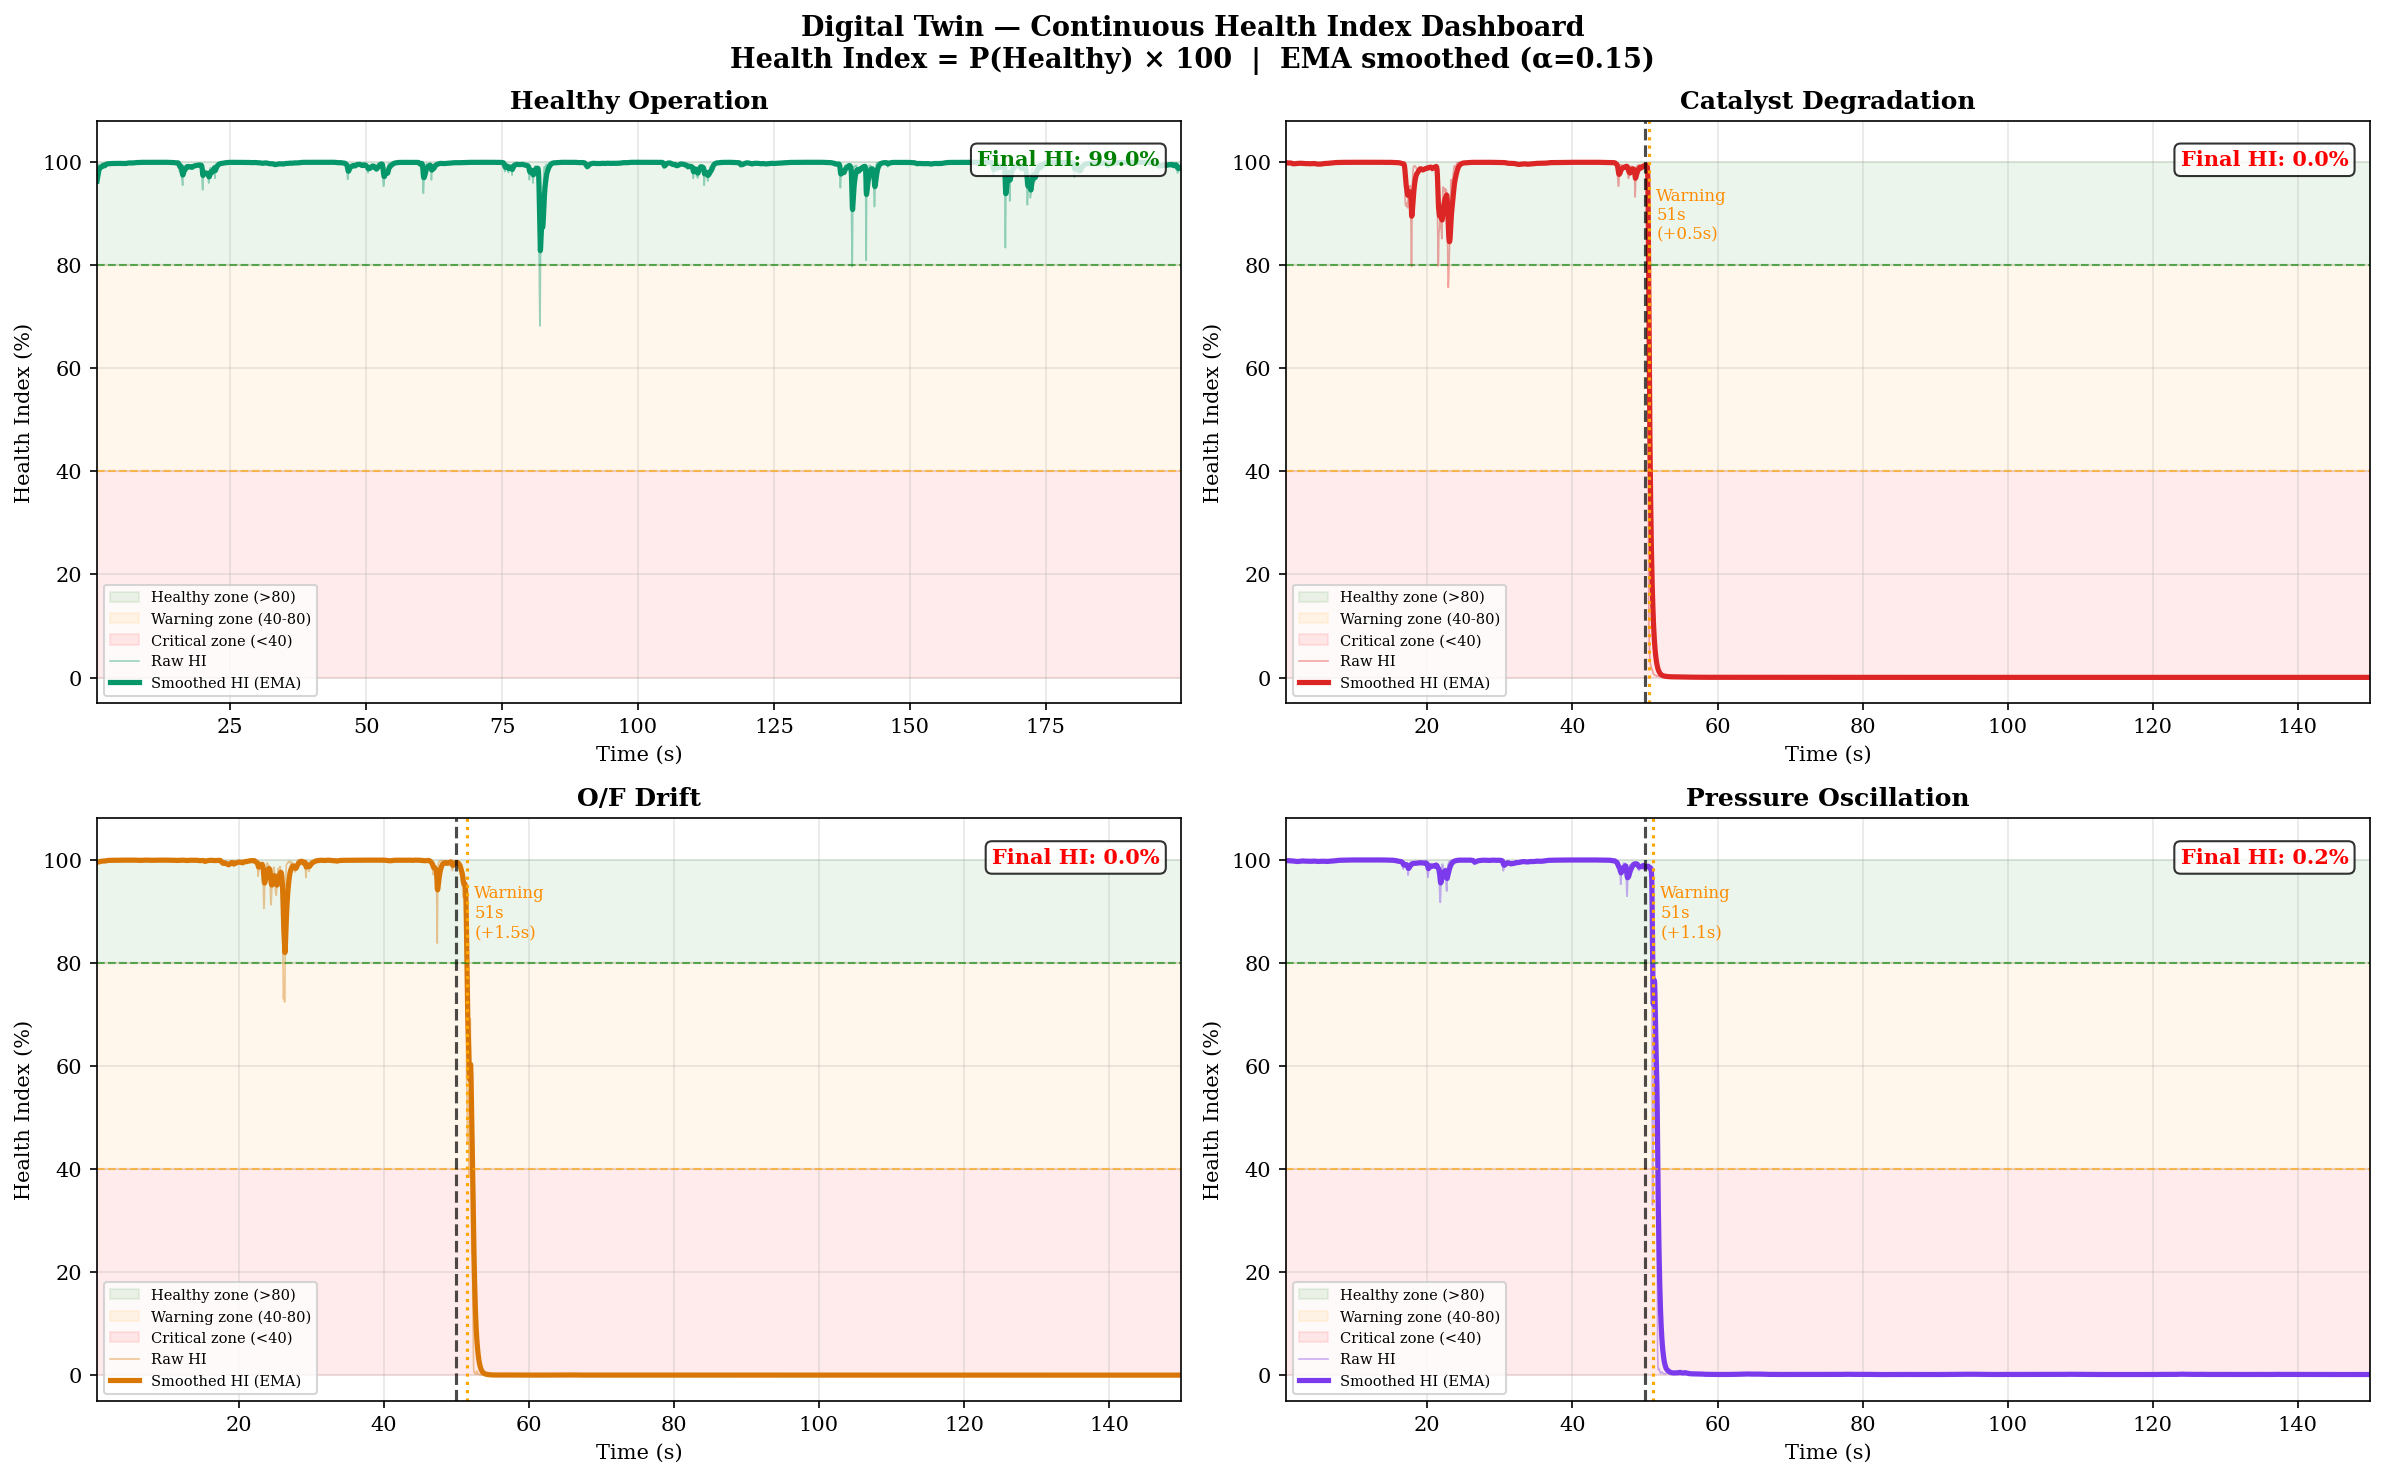


✓ Cell 12 complete.
  Health Index dashboard generated.
  Warning zone detection times:
  Healthy Operation        : min HI = 82.8% (stays healthy ✓)
  Catalyst Degradation     : warning at 50.5s (+0.5s after onset)
  O/F Drift                : warning at 51.5s (+1.5s after onset)
  Pressure Oscillation     : warning at 51.1s (+1.1s after onset)


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 12 — Continuous Health Index
# Single scalar metric 0-100 representing system health
# More useful operationally than binary fault/no-fault
# ══════════════════════════════════════════════════════════════

print("Computing continuous health index...")

def compute_health_index(model, scaler, data_dict,
                          window_size=WINDOW_SIZE, step=5):
    """
    Compute continuous health index from sensor stream.

    Health Index = 100 × P(healthy class)
    Smoothed with exponential moving average.
    0 = certain fault, 100 = certain healthy.
    """
    df_hi = pd.DataFrame({
        'P_c_meas'      : data_dict['P_c_meas'],
        'T_c_meas'      : data_dict['T_c_meas'],
        'thrust_meas'   : data_dict['thrust_meas'],
        'mdot_ox_meas'  : data_dict['mdot_ox_meas'],
        'mdot_fuel_meas': data_dict['mdot_fuel_meas'],
        'cstar_eff_meas': data_dict['cstar_eff_meas'],
    })

    values = df_hi[FEATURES].values
    t_arr  = data_dict['t']
    t_hi   = []
    hi_raw = []

    for i in range(0, len(values) - window_size, step):
        w        = values[i:i+window_size]
        w_scaled = scaler.transform(w)
        w_input  = w_scaled.reshape(1, window_size, len(FEATURES))
        probs    = model.predict(w_input, verbose=0)[0]
        # Health = probability of being healthy
        hi_raw.append(probs[0] * 100)
        t_hi.append(t_arr[i + window_size - 1])

    t_hi   = np.array(t_hi)
    hi_raw = np.array(hi_raw)

    # Exponential moving average smoothing
    alpha  = 0.15
    hi_ema = np.zeros_like(hi_raw)
    hi_ema[0] = hi_raw[0]
    for i in range(1, len(hi_raw)):
        hi_ema[i] = alpha * hi_raw[i] + (1-alpha) * hi_ema[i-1]

    return t_hi, hi_raw, hi_ema


# Compute health index for all fault scenarios
print("Computing health indices for all scenarios...")
scenarios = {
    'Healthy Operation'     : healthy_data,
    'Catalyst Degradation'  : fault_cat,
    'O/F Drift'             : fault_of,
    'Pressure Oscillation'  : fault_posc,
}

hi_results = {}
for sname, sdata in scenarios.items():
    print(f"  {sname}...")
    t_hi, hi_raw, hi_ema = compute_health_index(
        model, scaler, sdata
    )
    hi_results[sname] = {
        't': t_hi, 'raw': hi_raw, 'ema': hi_ema
    }

# ── Figure: Health index dashboard ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Digital Twin — Continuous Health Index Dashboard\n'
    'Health Index = P(Healthy) × 100  |  '
    'EMA smoothed (α=0.15)',
    fontsize=13, fontweight='bold'
)

axes_flat  = axes.flatten()
scolors    = ['#059669', '#DC2626', '#D97706', '#7C3AED']
onset_t    = 50.0  # fault onset time for fault scenarios

for ax, (sname, res), color in zip(
    axes_flat, hi_results.items(), scolors
):
    t   = res['t']
    raw = res['raw']
    ema = res['ema']

    # Background shading
    ax.axhspan(80, 100, alpha=0.08, color='green',
               label='Healthy zone (>80)')
    ax.axhspan(40, 80, alpha=0.08, color='orange',
               label='Warning zone (40-80)')
    ax.axhspan(0, 40, alpha=0.08, color='red',
               label='Critical zone (<40)')

    ax.plot(t, raw, color=color, lw=0.8,
            alpha=0.4, label='Raw HI')
    ax.plot(t, ema, color=color, lw=2.5,
            label='Smoothed HI (EMA)')

    # Threshold lines
    ax.axhline(80, color='green',  ls='--', lw=1, alpha=0.6)
    ax.axhline(40, color='orange', ls='--', lw=1, alpha=0.6)

    # Fault onset marker for fault scenarios
    if sname != 'Healthy Operation':
        ax.axvline(onset_t, color='black',
                   ls='--', lw=1.5, alpha=0.7)
        # Find when HI drops below 80
        post_onset = t[t > onset_t]
        ema_post   = ema[t > onset_t]
        warning    = np.where(ema_post < 80)[0]
        if len(warning) > 0:
            t_warn  = post_onset[warning[0]]
            delay   = t_warn - onset_t
            ax.axvline(t_warn, color='orange',
                       ls=':', lw=1.5)
            ax.text(t_warn + 1, 85,
                    f'Warning\n{t_warn:.0f}s\n(+{delay:.1f}s)',
                    fontsize=8, color='darkorange')

    ax.set_xlim(t[0], t[-1])
    ax.set_ylim(-5, 108)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Health Index (%)')
    ax.set_title(sname, fontweight='bold')
    ax.legend(fontsize=7, loc='lower left')

    # Current health annotation
    final_hi = ema[-1]
    ax.text(0.98, 0.95, f'Final HI: {final_hi:.1f}%',
            transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            fontweight='bold',
            color='green' if final_hi > 80
                  else 'orange' if final_hi > 40
                  else 'red',
            bbox=dict(boxstyle='round', facecolor='white',
                      alpha=0.8))

plt.tight_layout()
plt.savefig('dt_fig8_health_index.png',
            dpi=200, bbox_inches='tight')
plt.show()

print(f"\n✓ Cell 12 complete.")
print(f"  Health Index dashboard generated.")
print(f"  Warning zone detection times:")
for sname, res in hi_results.items():
    if sname == 'Healthy Operation':
        min_hi = res['ema'].min()
        print(f"  {sname:25s}: min HI = {min_hi:.1f}% "
              f"(stays healthy ✓)")
    else:
        ema_post = res['ema'][res['t'] > onset_t]
        warning  = np.where(ema_post < 80)[0]
        if len(warning) > 0:
            t_post  = res['t'][res['t'] > onset_t]
            t_warn  = t_post[warning[0]]
            print(f"  {sname:25s}: warning at {t_warn:.1f}s "
                  f"(+{t_warn-onset_t:.1f}s after onset)")